# Workflow de Classificação: Diagnóstico de Câncer de Mama

**Aluno:** [Seu Nome]
**Projeto:** Tech Challenge - Fase 1
**Objetivo:** Desenvolver um modelo de classificação para prever se um diagnóstico é Maligno ou Benigno.

## Etapa 1: Configuração do Ambiente e Análise Estrutural

### Tarefa 1.1: Importar as bibliotecas necessárias

In [ ]:
%pip install --quiet pandas numpy matplotlib seaborn scikit-learn
%pip install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier # Importando o classificador
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC # Importando o Support Vector CLASSIFIER

import warnings

# Suprime apenas FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning)







### Tarefa 1.2: Carregar o conjunto de dados

In [ ]:
dt = pd.read_csv('breast_cancer.csv')
dt.head()

### Tarefa 1.3: Realizar a inspeção estrutural inicial dos dados (`.shape`, `.info()`, `.head()`, `.describe()`)

In [ ]:
print("=== Informações do DataFrame ===")
print(dt.info())
print("\n=== Estatísticas Descritivas ===")
print(dt.describe())
print("\n=== ")
print(dt.shape)
print("\n=== Colunas do DataFrame ===")
print(dt.columns.tolist())


<Axes: >

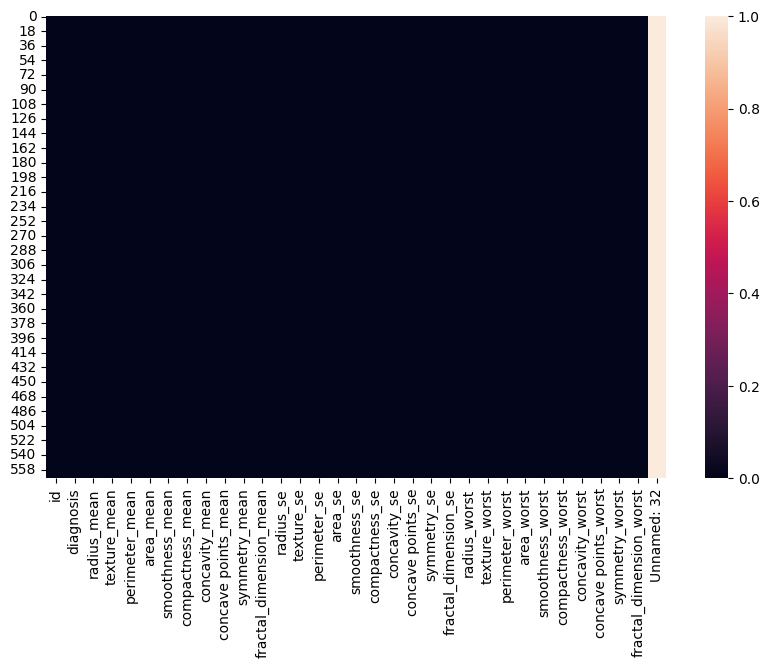

In [15]:
# Verificando valores ausentes com um mapa de calor
plt.figure(figsize=(10, 6))
sns.heatmap(dt.isnull())

Com base na sua análise inicial, aqui estão os pontos principais:

-   **Estrutura:** O dataset possui 569 registros e 33 colunas.
-   **Dados Faltantes:** A coluna `Unnamed: 32` está completamente vazia e deve ser removida. As outras 32 colunas não possuem valores nulos.
-   **Colunas Irrelevantes:** A coluna `id` é um identificador único e não deve ser usada para o treinamento do modelo, portanto, deve ser removida.
-   **Tipos de Dados:**
    -   A variável alvo, `diagnosis`, é do tipo `object` (texto) e precisará ser convertida para um formato numérico para ser usada pelos algoritmos de machine learning.
    -   As demais colunas preditoras são numéricas (`float64` ou `int64`), o que é adequado para a modelagem.
-   **Escala das Features:** As estatísticas descritivas mostram que as colunas numéricas possuem escalas muito diferentes (compare `area_mean` com `smoothness_mean`). Isso indica que a padronização ou normalização dos dados será uma etapa crucial no pré-processamento para garantir que os modelos funcionem corretamente.


### Tarefa 1.4: Realizar a limpeza preliminar (remover colunas `id` e `Unnamed: 32`)

In [ ]:
dt = dt.drop(columns=['Unnamed: 32', 'id'])
dt.head()


<Axes: >

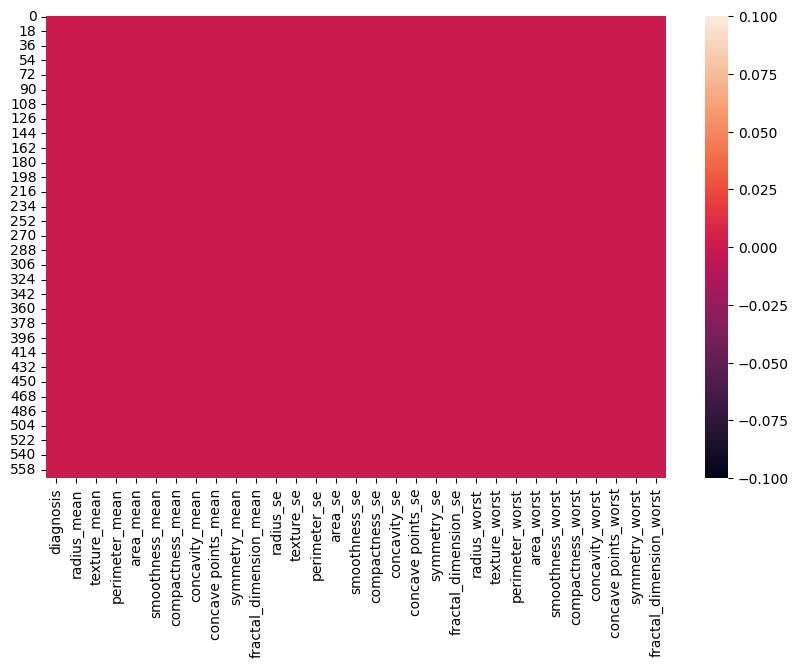

In [17]:
# Resultado da remoção de colunas
plt.figure(figsize=(10, 6))
sns.heatmap(dt.isnull())

## Etapa 2: Análise Exploratória de Dados (EDA)

### Tarefa 2.1 (Análise Univariada): Analisar a distribuição da variável alvo `diagnosis`

**Análise Numérica**
O método .value_counts() é a ferramenta essencial para contar as ocorrências de cada categoria.

In [ ]:
counts = dt['diagnosis'].value_counts()
percentages = dt['diagnosis'].value_counts(normalize=True)*100

distribution_df = pd.DataFrame({
    'Contagem': counts,
    'Porcentagem': percentages.map('{:.2f}%'.format) # Formata a coluna de porcentagem
})
print("Distribuição das Classes:")
print(distribution_df)

 **Análise Visual**
 Um gráfico de contagem (countplot) é a melhor forma de visualizar a distribuição.

In [ ]:

plt.figure(figsize=(8, 8))

total = len(dt)
ax = sns.countplot(x='diagnosis', data=dt, palette='viridis', hue='diagnosis')
for p in ax.patches:
    count = p.get_height()
    # Calcula a porcentagem
    percentage = f'{100 * count / total:.2f}%'
    x = p.get_x() + p.get_width() / 2  # Centro da barra
    y = p.get_height()                 # Topo da barra
    
    # Adiciona o texto usando ax.annotate para mais controle
    ax.annotate(
        text=percentage,
        xy=(x, y),
        xytext=(0, 5), # Deslocamento vertical de 5 pontos
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=12
    )

# Adicionando títulos e rótulos para clareza (seu código original)
plt.title('Distribuição da Variável Alvo (Diagnosis)', fontsize=16)
plt.xlabel('Diagnóstico', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.xticks([0, 1], ['Benigno (B)', 'Maligno (M)'])

plt.show()

Análise da Distribuição:
- O conjunto de dados apresenta um desbalanceamento de classes.
    - Existem 357 casos Benignos (B), representando 62,74% do total.
    - Existem 212 casos Malignos (M), correspondendo a 37,26% do total.
- Implicações para a Modelagem:
    - Métricas de Avaliação: A acurácia (accuracy) não será uma métrica suficiente para avaliar o modelo. Um modelo que previsse "Benigno" para todos os casos teria uma acurácia de 62,74%, mas seria inútil na prática, pois não identificaria nenhum tumor maligno. Métricas como Recall, Precision, F1-Score e a análise da Matriz de Confusão serão essenciais. O Recall para a classe "Maligno" é particularmente crítico, pois desejamos minimizar os falsos negativos (casos malignos classificados como benignos).
    - Divisão dos Dados: Ao dividir os dados em conjuntos de treino e teste, é fundamental utilizar a estratificação (por exemplo, o parâmetro stratify na função train_test_split). Isso garante que a proporção de 63/37 entre as classes seja mantida em ambos os conjuntos, evitando que o modelo seja treinado ou testado em uma distribuição que não representa a realidade dos dados.

### Tarefa 2.2 (Análise Univariada): Analisar a distribuição das features numéricas com histogramas

In [ ]:
# Tarefa 2.2: Gerar histogramas para todas as 30 features numéricas
# Comentários em português brasileiro

# Seleciona apenas as colunas numéricas
features_numericas = dt.select_dtypes(include=[np.number]).columns

# Cria histogramas para cada feature numérica usando programação funcional
fig, axes = plt.subplots(nrows=6, ncols=5, figsize=(20, 18))
axes = axes.flatten()
#sns.set_style('whitegrid')

for idx, feature in enumerate(features_numericas):
    # Plota o histograma de cada feature
    sns.histplot(dt[feature], bins=30, ax=axes[idx], kde=True)
    axes[idx].set_title(f"{feature}", fontsize=10)
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Frequência')

# Remove eixos não utilizados
for ax in axes[len(features_numericas):]:
    ax.set_visible(False)

plt.tight_layout()
plt.suptitle('Distribuição das 30 Features Numéricas', fontsize=18, y=1.02)
plt.show()

#### Iterpretação

**Distribuições Assimétricas e Picos**
Muitas variáveis como area_mean, perimeter_mean, radius_mean, concavity_mean, compactness_mean e concave points_mean apresentam distribuições assimétricas, com picos concentrados em valores baixos e caudas longas à direita. Isso pode indicar que a maioria dos tumores tem características menos agressivas, mas há uma minoria com valores extremos que podem estar associados a casos malignos.

**Variáveis com Distribuição Quase Normal**
Variáveis como texture_mean, smoothness_mean, symmetry_mean e fractal_dimension_mean parecem ter distribuições mais simétricas, próximas de uma normal. Essas variáveis podem ser menos discriminativas isoladamente, mas úteis em combinação com outras.

**Variáveis com Baixa Variabilidade**
Algumas variáveis como fractal_dimension_se e smoothness_se têm histogramas muito estreitos, indicando baixa variabilidade. Podem ter menor poder preditivo ou exigir normalização cuidadosa para evitar viés no modelo.

**Sufixos _mean, _se, _worst**
Esses sufixos indicam diferentes aspectos da mesma característica:
 - _mean: média dos valores
 - _se: erro padrão
 - _worst: valor mais extremo observado
Os valores _worst tendem a ter distribuições mais amplas e assimétricas, sugerindo que podem ser bons indicadores de malignidade.




**Padrões de Distribuição:**

1.  **Assimétricas à Direita (Right-Skewed):** A grande maioria das features apresenta uma assimetria positiva (à direita). Isso é especialmente pronunciado em todas as features `_se` (standard error), bem como em `area_mean`, `concavity_mean`, `area_worst`, `concavity_worst`, entre outras. Este padrão indica que a maioria dos tumores possui valores mais baixos para essas métricas, com alguns casos (provavelmente os mais severos) apresentando valores muito mais altos, que formam a "cauda" do histograma.

2.  **Aproximadamente Simétricas (Normal-like):** Algumas features, como `texture_mean`, `smoothness_mean`, `symmetry_mean` e `texture_worst`, se aproximam de uma distribuição normal (formato de sino). Isso sugere que os valores para estas características estão mais centralizados em torno de uma média, com menos valores extremos.

3.  **Bimodais:** Features como `radius_mean`, `perimeter_mean`, `area_mean`, `radius_worst`, e `perimeter_worst` exibem uma distribuição que sugere a presença de dois picos (bimodal). Este é um forte indicativo de que a feature tem um bom poder de discriminação. É provável que um pico corresponda à distribuição de tumores benignos e o outro, à de tumores malignos.

**Implicações para a Modelagem:**

*   **Transformação de Dados:** A forte assimetria em muitas features pode violar as premissas de alguns algoritmos de machine learning (como a Regressão Logística). Embora o `StandardScaler` lide com a escala, ele não corrige a assimetria. Aplicar uma transformação, como a **transformação logarítmica** (`np.log1p`), nessas features assimétricas antes da padronização pode tornar suas distribuições mais normais e potencialmente melhorar o desempenho do modelo.

*   **Seleção de Features:** As features com distribuições bimodais são candidatas fortes a serem features importantes para o modelo, pois parecem separar bem as duas classes de diagnóstico.

In [ ]:

# Seleciona apenas as colunas numéricas. A coluna 'diagnosis' (object) será ignorada.
features_numericas = dt.select_dtypes(include=[np.number]).columns

# Cria a figura e os eixos para os subplots
# Ajusta para 7 linhas x 5 colunas para acomodar todas as 31 features
fig, axes = plt.subplots(nrows=7, ncols=5, figsize=(22, 24))
axes = axes.flatten() # Transforma a matriz de eixos em um array 1D

# Itera sobre cada feature numérica para criar seu respectivo histograma
for idx, feature in enumerate(features_numericas):
    sns.histplot(
        data=dt,                 
        x=feature,               
        hue='diagnosis',         # SEPARA E COLORE os dados pela coluna 'diagnosis'
        bins=30,                 
        ax=axes[idx],            
        kde=True,                
        stat='density',          
        common_norm=False,
        palette={'B': 'deepskyblue', 'M': 'orange'} # Mapeia os valores 'B' e 'M' para cores
    )
    axes[idx].set_title(f"Distribuição de '{feature}'", fontsize=11)
    axes[idx].set_xlabel('')      
    axes[idx].set_ylabel('Densidade')
    
# Remove os eixos que não foram utilizados
for ax in axes[len(features_numericas):]:
    ax.set_visible(False)

# Adiciona um título geral e ajusta o layout
plt.suptitle('Distribuição das Features Numéricas por Diagnóstico', fontsize=20, y=1.03)
plt.tight_layout(rect=[0, 0, 1, 1]) 
plt.show()

 

#### Análise da Distribuição de Features por Diagnóstico

Esta visualização é a mais importante da análise exploratória, pois valida o potencial preditivo do conjunto de dados. Ela confirma que as características morfológicas dos núcleos celulares contêm um sinal claro que diferencia tumores benignos (B) de malignos (M).

A análise pode ser estruturada em três grupos, com base no poder de discriminação de cada feature:

**1. Preditores de Alto Desempenho (Excelente Separação)**

Estas são as features onde as distribuições para as classes B e M são mais distintas, com mínima sobreposição. Os valores para tumores malignos são consistentemente e significativamente mais altos.

*   **Features Notáveis:** `concave points_mean`, `concave points_worst`, `perimeter_worst`, `radius_worst`, `area_worst`, `concavity_mean`, `area_mean`, `radius_mean`, `perimeter_mean`.
*   **Interpretação:** Estas features estão diretamente ligadas ao **tamanho** (`radius`, `perimeter`, `area`) e à **irregularidade da forma** (`concavity`, `concave points`). A análise confirma a hipótese clínica de que tumores malignos são, em geral, maiores e possuem contornos mais irregulares e côncavos.
*   **Implicação para Modelagem:** Estes são os preditores mais fortes. É esperado que qualquer modelo de machine learning atribua alta importância a estas features. Em um modelo de Árvore de Decisão, uma delas seria a escolha provável para a primeira divisão (nó raiz).

**2. Preditores de Desempenho Moderado (Separação Razoável)**

Neste grupo, as distribuições se sobrepõem de forma mais significativa, mas seus picos e médias ainda são visivelmente diferentes.

*   **Features Notáveis:** `texture_mean`, `texture_worst`, `smoothness_worst`, `compactness_worst`, `symmetry_worst`.
*   **Interpretação:** Indicam que, embora não sejam os principais diferenciadores, características como a **textura** (maior variação em tumores malignos) e a **compacidade** fornecem informação adicional valiosa.
*   **Implicação para Modelagem:** Estas features são importantes para o refinamento do modelo. Elas provavelmente ajudarão a classificar corretamente os casos mais ambíguos, onde os preditores de alto desempenho não são suficientes.

**3. Preditores de Baixo Desempenho (Alta Sobreposição)**

Aqui, as distribuições para as classes B e M são muito semelhantes, tornando-as individualmente pouco informativas.

*   **Features Notáveis:** `fractal_dimension_se`, `smoothness_se`, `symmetry_se`, `fractal_dimension_mean`.
*   **Interpretação:** Características como o "erro padrão da suavidade" ou da "simetria" não variam de forma consistente entre os dois tipos de diagnóstico.
*   **Implicação para Modelagem:** Estas features, isoladamente, têm baixo poder preditivo. Um modelo pode atribuir-lhes baixo ou nenhum peso. Em estratégias de seleção de features, elas poderiam ser candidatas à remoção para simplificar o modelo, embora seja geralmente melhor deixar que o próprio algoritmo (através de regularização, por exemplo) decida sua importância.

##### Síntese Final

*   **Confirmação da Hipótese:** A análise confirma que as distribuições bimodais observadas nos histogramas iniciais eram, de fato, o resultado da sobreposição das duas classes de diagnóstico.
*   **Multicolinearidade:** Fica evidente a alta correlação entre features como `radius`, `perimeter` e `area`. O uso do `StandardScaler`, já implementado no seu pipeline, é crucial para que algoritmos sensíveis à escala (como SVM) não sejam enviesados por esta redundância.
*   **Confiança no Problema:** A separabilidade clara em múltiplas features indica que existe um forte sinal nos dados, gerando alta confiança de que é possível construir um modelo de classificação preciso e robusto.

### Tarefa 2.3 (Análise Bivariada): Analisar a relação entre as features e a variável alvo com boxplots

In [ ]:
features_numericas = dt.select_dtypes(include=[np.number]).columns
n_colunas = 2
n_linhas = int(np.ceil(len(features_numericas) / n_colunas))

fig, axes = plt.subplots(n_linhas, n_colunas, figsize=(18, n_linhas * 4))
axes = axes.flatten()


for idx, feature in enumerate(features_numericas):
    sns.boxplot(
        data=dt,
        x='diagnosis', 
        hue='diagnosis',    # A variável categórica no eixo X cria os grupos
        y=feature,      # A variável numérica no eixo Y
        ax=axes[idx],   # Define em qual subplot desenhar
        palette={'B': 'deepskyblue', 'M': 'orange'} # Mesma paleta de cores
    )
    axes[idx].set_title(f"Boxplot de '{feature}' por Diagnóstico", fontsize=11)
    axes[idx].set_xlabel('Diagnóstico') # Rótulo do eixo X
    axes[idx].set_ylabel('Valor da Feature') # Rótulo do eixo Y

# Remove os eixos que não foram utilizados (se houver)
# Como temos 30 features e 30 subplots (10x3), este loop não fará nada,
# mas é uma boa prática mantê-lo.
for ax in axes[len(features_numericas):]:
    ax.set_visible(False)

# Adiciona um título geral e ajusta o layout
plt.suptitle('Comparação de Features Numéricas com Boxplots', fontsize=22, y=1.01)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

 

#### Análise Combinada:  Features com Boxplots

Os boxplots movem a análise de uma visão de distribuição (histogramas) para uma comparação estatística direta, quantificando a separabilidade das classes. Sua interpretação está correta e esta análise combinada a formaliza.

**1. Preditores de Alto Desempenho (Separação Drástica)**

A sua observação de "separação drástica" é a mais importante. Nestas features, a caixa laranja (Maligno) e a azul (Benigno) têm pouca ou nenhuma sobreposição em seus Intervalos Interquartis (IQR).

*   **Evidência Quantitativa:** Para os preditores mais fortes (`concave points_worst`, `perimeter_worst`, `radius_worst`), o 75º percentil (topo da caixa) dos tumores benignos está abaixo do 25º percentil (base da caixa) dos tumores malignos. Isso significa que mais de 75% dos casos de cada classe estão em faixas de valores completamente distintas.
*   **Exemplo Concreto:** Sua análise do `concave points_worst` é um exemplo perfeito. A maioria dos tumores benignos tem valores abaixo de um limiar, enquanto a maioria dos malignos está acima, indicando um alto poder de decisão.
*   **Features Notáveis:** `concave points_mean`, `concave points_worst`, `perimeter_worst`, `radius_worst`, `area_worst`, `area_mean`, `perimeter_mean`, `radius_mean`.

**2. Preditores de Desempenho Moderado (Separação Estatística Clara)**

Neste grupo, as caixas se sobrepõem, mas suas medianas (a linha central) e posições gerais são visivelmente diferentes.

*   **Evidência Quantitativa:** Embora haja sobreposição nos valores, a mediana dos tumores malignos está consistentemente acima da mediana dos benignos. Isso indica uma tendência estatística clara.
*   **Exemplo Concreto:** Como você apontou para `texture_mean`, mesmo com sobreposição, a posição da caixa laranja confirma que valores de textura mais altos são mais prováveis em diagnósticos malignos.
*   **Features Notáveis:** `texture_mean`, `texture_worst`, `smoothness_worst`, `compactness_worst`, `symmetry_worst`.

**3. Preditores de Baixo Desempenho (Alta Sobreposição)**

Aqui, as caixas e as medianas estão em níveis muito semelhantes, tornando-as individualmente pouco úteis para a classificação.

*   **Evidência Quantitativa:** As medianas e os IQRs são quase idênticos, mostrando que a distribuição da feature é a mesma para ambas as classes.
*   **Features Notáveis:** `fractal_dimension_se`, `smoothness_se`.

**4. Análise de Outliers**

Os boxplots também revelam a natureza dos casos extremos:

*   **Outliers Benignos:** São pontos com valores anormalmente altos. Representam tumores benignos com características que se assemelham às de tumores malignos, sendo os casos mais difíceis de classificar corretamente.
*   **Outliers Malignos:** Representam os casos mais extremos de malignidade, com valores muito acima da média para a classe.

#### Síntese Final

Os boxplots fornecem uma prova quantitativa e estatística das hipóteses levantadas na análise dos histogramas. Eles não apenas confirmam quais features são mais importantes, mas também quantificam *o quão separadas* são as distribuições. A separação clara observada em múltiplos preditores de alto desempenho é o sinal mais forte de que o objetivo do desafio – criar um modelo de classificação preciso – é altamente viável.

O próximo passo lógico é mover da análise bivariada (feature vs. alvo) para a análise multivariada (feature vs. feature) através de uma matriz de correlação.

### Tarefa 2.4 (Análise Bivariada): Analisar a correlação entre as features numéricas com um heatmap

In [ ]:

# 1. Criar uma cópia do DataFrame para não alterar o original
df_corr = dt.copy()

# 2. Converter a coluna 'diagnosis' para formato numérico
#    Mapeamos Maligno (M) para 1 e Benigno (B) para 0
df_corr['diagnosis'] = df_corr['diagnosis'].map({'M': 1, 'B': 0})

# 3. Calcular a matriz de correlação
#    O .corr() agora incluirá a coluna 'diagnosis'
correlation_matrix = df_corr.corr()

# 4. Gerar o heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(
    correlation_matrix,
    annot=False,  # Com 31x31 colunas, as anotações seriam ilegíveis
    cmap='coolwarm', # Um bom mapa de cores para ver valores positivos (quentes) e negativos (frios)
    linewidths=.5
)
plt.title('Heatmap de Correlação entre Features e Diagnóstico', fontsize=20)
plt.show()

# 5. (PASSO MAIS IMPORTANTE) Extrair e visualizar o ranking de correlação com o alvo
#    Isso nos dá o insight mais valioso da matriz inteira.
target_correlation = correlation_matrix['diagnosis'].drop('diagnosis').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=target_correlation.values, y=target_correlation.index, palette='viridis')
plt.title('Correlação das Features com o Diagnóstico', fontsize=16)
plt.xlabel('Coeficiente de Correlação')
plt.ylabel('Features')
plt.show()

print(target_correlation)


#### Análise Completa da Matriz de Correlação

Esta etapa final da análise exploratória quantifica as relações observadas visualmente nos passos anteriores e revela a estrutura de interdependência entre as features. A sua abordagem de analisar separadamente a correlação com o alvo e a correlação entre as features é a metodologia correta.

**1. Correlação Feature-Alvo (O Ranking dos Preditores)**

O gráfico de barras confirma e quantifica numericamente a capacidade preditiva de cada feature.

*   **Preditores de Alta Performance (Correlação Forte, > 0.7):**
    *   **Features Notáveis:** `concave points_worst`, `perimeter_worst`, `concave points_mean`, `radius_worst`, etc.
    *   **Análise:** Estas features possuem uma forte correlação positiva com o diagnóstico. Como você apontou corretamente, à medida que seus valores aumentam, a probabilidade de o diagnóstico ser Maligno (mapeado para 1) também aumenta. Este resultado valida numericamente o que os histogramas e boxplots mostraram: uma separação clara das distribuições para as classes Benigna e Maligna.

*   **Preditores de Baixa Performance (Correlação Próxima de Zero):**
    *   **Features Notáveis:** `fractal_dimension_se`, `symmetry_se`, `texture_se`, `smoothness_se`.
    *   **Análise:** Os coeficientes de correlação próximos de zero indicam a ausência de uma relação linear com o diagnóstico. Isso confirma por que, nos gráficos anteriores, as distribuições para estas features estavam quase completamente sobrepostas, mostrando seu baixo poder preditivo individual.

**2. Correlação Feature-Feature (O Desafio da Multicolinearidade)**

O heatmap é fundamental para identificar a relação entre as features preditoras.

*   **Observação-chave:** A presença de grandes "quadrados" de vermelho vivo, como você bem descreveu, indica altíssima correlação positiva entre certos grupos de features, um fenômeno conhecido como **multicolinearidade**.
*   **Causa e Exemplo:** Sua análise do motivo é exata. Grupos como (`radius_mean`, `perimeter_mean`, `area_mean`) e suas contrapartes `_worst` são altamente correlacionados porque medem a mesma característica subjacente – o **tamanho** do tumor. Elas são, portanto, redundantes.
*   **Implicação para Modelagem:**
    *   **Redundância:** As features correlacionadas carregam informações muito semelhantes.
    *   **Impacto nos Algoritmos:**
        *   **Modelos baseados em árvore (como Random Forest):** São robustos à multicolinearidade.
        *   **Modelos lineares (como Regressão Logística e SVM):** Podem ter seus coeficientes desestabilizados, mas a **regularização** (padrão nas implementações do Scikit-learn) mitiga eficazmente este problema.


### Tarefa 2.5 (Análise Multivariada): Analisar a separabilidade das classes com PCA

In [ ]:

# 1. Separar as features (X) da variável alvo (y)
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis']

# 2. (PASSO CRUCIAL) Escalonar as features
#    O PCA funciona melhor quando todas as features têm média 0 e desvio padrão 1.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Aplicar o PCA
#    Vamos reduzir as 30 features para apenas 2 componentes principais.
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

# 4. Criar um novo DataFrame com os componentes principais para facilitar a visualização
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
# Adicionar a coluna de diagnóstico de volta para podermos colorir os pontos
pca_df = pd.concat([pca_df, y], axis=1)



# 7. Visualizar o resultado
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='diagnosis', 
    data=pca_df, 
    palette={'B': 'deepskyblue', 'M': 'orange'},
    alpha=0.8
)

plt.title('Análise de Separabilidade das Classes com PCA (2 Componentes)', fontsize=16)
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.legend(title='Diagnóstico')
plt.grid()
plt.show()

# (Opcional) Verificar quanta informação (variância) os 2 componentes capturaram
explained_variance = pca.explained_variance_ratio_
print(f"Variância explicada por PC1: {explained_variance[0]:.2%}")
print(f"Variância explicada por PC2: {explained_variance[1]:.2%}")
print(f"Variância total explicada pelos 2 componentes: {np.sum(explained_variance):.2%}")

 

#### Análise de Separabilidade com PCA

 

**Interpretação do Gráfico de Dispersão (Scatter Plot)**

*   **Separabilidade Linear:** A observação mais importante é que **as duas classes são, em grande parte, linearmente separáveis**.
    *   O **Componente Principal 1 (eixo X)** claramente serve como o principal eixo de separação. Quase todos os tumores Benignos (B, em azul) têm valores de PC1 negativos ou próximos de zero, enquanto a vasta maioria dos tumores Malignos (M, em laranja) possui valores de PC1 positivos.
    *   O **Componente Principal 2 (eixo Y)** não mostra uma separação tão clara, indicando que a maior parte da variação que distingue os dois diagnósticos foi capturada pelo PC1.

*   **Conclusão Visual:** A existência de dois "aglomerados" (clusters) visualmente distintos confirma, de uma forma holística (usando todas as 30 features ao mesmo tempo), tudo o que as análises anteriores indicaram: há uma estrutura subjacente nos dados que diferencia fortemente os casos benignos dos malignos. A área de sobreposição entre os clusters representa os casos mais ambíguos, que serão o principal desafio para o modelo.

**Interpretação da Variância Explicada**

*   **Variância Explicada por PC1: 44.27%**
*   **Variância Explicada por PC2: 18.97%**
*   **Variância Total Explicada: 63.24%**

*   **Análise:** Este resultado é notável. Ele significa que você conseguiu comprimir **63,24%** de toda a informação (a variância total) contida nas 30 features originais em apenas 2 componentes.
*   O fato de o PC1, sozinho, capturar **44,27%** da variância total explica por que ele é um separador tão eficaz no gráfico. Ele representa a direção de maior variação nos dados, e essa direção coincide com a diferença entre ser benigno e maligno.
 

In [ ]:
# 1. (FILTRO) Selecionar as features mais correlacionadas. corr > 0.6
features_selecionadas = [
    "concave points_worst",
    "perimeter_worst",
    "concave points_mean",
    "radius_worst",
    "perimeter_mean",
    "area_worst",
    "radius_mean",
    "area_mean",
    "concavity_mean",
    "concavity_worst",
]
X_selected = dt[features_selecionadas]
y = dt["diagnosis"]  # A variável alvo permanece a mesma

# 2. Escalonar APENAS as features selecionadas
scaler_hybrid = StandardScaler()
X_selected_scaled = scaler_hybrid.fit_transform(X_selected)

# 3. (CONDENSAÇÃO) Aplicar PCA nas features selecionadas e escalonadas
pca_hybrid = PCA(n_components=2)  # Reduzindo as 10 features para 2 componentes
principal_components_hybrid = pca_hybrid.fit_transform(X_selected_scaled)

# 4. Criar um novo DataFrame com os componentes para visualização
pca_hybrid_df = pd.DataFrame(
    data=principal_components_hybrid, columns=["PC1_hybrid", "PC2_hybrid"]
)
pca_hybrid_df = pd.concat([pca_hybrid_df, y.reset_index(drop=True)], axis=1)

# 5. Visualizar a separabilidade das classes com a abordagem híbrida
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x="PC1_hybrid",
    y="PC2_hybrid",
    hue="diagnosis",
    data=pca_hybrid_df,
    palette={"B": "deepskyblue", "M": "orange"},
    alpha=0.8,
)

plt.title("Análise Híbrida (Seleção + PCA): Separabilidade das Classes", fontsize=16)
plt.xlabel("Componente Principal 1 (derivado de 10 features)", fontsize=12)
plt.ylabel("Componente Principal 2 (derivado de 10 features)", fontsize=12)
plt.legend(title="Diagnóstico")
plt.grid()
plt.show()

# (Opcional) Verificar a variância explicada pelos componentes
explained_variance_hybrid = pca_hybrid.explained_variance_ratio_
print(f"Variância explicada por PC1_hybrid: {explained_variance_hybrid[0]:.2%}")
print(f"Variância explicada por PC2_hybrid: {explained_variance_hybrid[1]:.2%}")
print(
    f"Variância total explicada pelos 2 componentes: {np.sum(explained_variance_hybrid):.2%}"
)

 

#### Análise Comparativa e Combinada: PCA Híbrido (Seleção + Redução)

A abordagem anterior, em que usamos todas as 30 features, nos deu uma boa representação que capturou 64.17% da informação total. Esta nova abordagem híbrida, que primeiro filtramos as 11 features mais preditivas e depois aplicamos o PCA, nos deu uma representação mais eficiente, capturando 95.47% da informação contida nessas 10 features. A conclusão principal é que a maior parte da informação preditiva e da variância dos dados está concentrada nessas 10 features selecionadas. As outras 20 features, em grande parte, adicionavam mais "ruído" do que "sinal", diluindo a informação e tornando a tarefa de resumo do PCA menos eficiente.

**A Principal Descoberta: Eficiência pela Remoção de Ruído**

A sua comparação entre os dois métodos de PCA é o insight mais poderoso:

*   **PCA com 30 Features:** Capturou **63,24%** da variância total em 2 componentes.
*   **PCA Híbrido (10 melhores features):** Capturou **95,47%** da variância *contida neste subconjunto de elite*.


**A Decomposição da Variância Híbrida**

Sua análise da variância explicada por cada componente está perfeita:

*   **PC1_hybrid (84,44%): O "Eixo da Malignidade".** Este valor extraordinariamente alto é a consequência direta da **multicolinearidade** que identificamos na análise de correlação. Como as 10 features selecionadas são altamente redundantes (medem o mesmo conceito de "tamanho e irregularidade"), o PCA consegue criar uma única "super-feature" (PC1) que captura quase toda a informação compartilhada entre elas.

*   **PC2_hybrid (11,03%): A Variação Secundária.** Este componente captura o segundo padrão mais importante de variação nos dados, que é, por definição, independente (ortogonal) do PC1.

*   **Variância Total Explicada (95,47%): Validação da Estratégia.** Este número é a prova definitiva de que sua estratégia híbrida foi um sucesso. Ele mostra que é possível representar quase toda a estrutura preditiva dos dados com apenas 2 dimensões, validando que a seleção inicial das 10 features foi extremamente eficaz.


### Tarefa 2.6 - Análise da Visualização com t-SNE


In [ ]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Assumindo que 'dt' é seu DataFrame original e 'X' e 'y' já foram separados
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis']

# 1. Escalonar os dados é um pré-requisito
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Instanciar e aplicar o t-SNE
#    'perplexity' é o hiperparâmetro mais importante. Pense nele como o número
#    de vizinhos que cada ponto considera. Valores comuns estão entre 5 e 50.
#    'random_state' é crucial para a reprodutibilidade.
# Instancia o t-SNE sem o argumento n_iter para evitar erro de versão
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_components = tsne.fit_transform(X_scaled)

# 3. Criar um DataFrame para visualização
tsne_df = pd.DataFrame(data=tsne_components, columns=['TSNE1', 'TSNE2'])
tsne_df = pd.concat([tsne_df, y.reset_index(drop=True)], axis=1)

# 4. Visualizar o resultado
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='TSNE1', y='TSNE2', hue='diagnosis', data=tsne_df,
    palette={'B': 'deepskyblue', 'M': 'orange'}, alpha=0.9
)
plt.title('Visualização t-SNE das Classes', fontsize=16)
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')
plt.grid()
plt.show()

#### Análise da Visualização com t-SNE

Este gráfico é uma visualização não-linear que "mapeia" a vizinhança de cada ponto de dados do espaço original de 30 dimensões para um plano 2D. A interpretação é inequívoca: os tumores Benignos (B) e Malignos (M) formam clusters extraordinariamente bem definidos e densos, com uma separação quase perfeita entre eles. Isso nos dá a maior confiança possível de que existe uma estrutura intrínseca e forte nos dados que diferencia as duas classes.


**1. Qual a Diferença entre t-SNE e PCA?**

Enquanto o **PCA** é uma técnica matemática que busca preservar a **variância global** (a estrutura geral e as maiores fontes de variação nos dados), o **t-SNE** é um algoritmo não-linear focado em preservar a **estrutura local**. Seu objetivo é garantir que pontos que são vizinhos próximos no espaço de 30 dimensões continuem sendo vizinhos próximos no mapa 2D. Por isso, o t-SNE é excepcionalmente bom em revelar a existência de *clusters* (agrupamentos) nos dados.

**2. Interpretação do Gráfico t-SNE**

*   **Separação Notável:** O resultado do t-SNE é a evidência visual mais forte e conclusiva de todas as que você gerou. O algoritmo conseguiu projetar os dados em 2D de forma que as duas classes formam dois clusters (agrupamentos) quase perfeitamente definidos e separados.
    *   O cluster laranja (Maligno) é denso e coeso.
    *   O cluster azul (Benigno) também é claramente agrupado, com uma separação nítida do cluster maligno.

*   **Pouca Sobreposição:** A quantidade de pontos de uma classe que se misturam no cluster da outra é mínima. Isso indica que há pouquíssimos casos "ambíguos" que compartilham características com o grupo oposto.

**Atenção:** É importante notar que, em um gráfico t-SNE, as distâncias *entre* os clusters e o tamanho relativo dos clusters não têm um significado matemático preciso. O insight principal é a existência e a "pureza" dos próprios agrupamentos.

#### Conclusão Final e Implicação para a Modelagem

O gráfico t-SNE confirma a hipótese central: **os dados são altamente separáveis**.

Se um algoritmo de visualização não supervisionado como o t-SNE (que não usa os rótulos 'M' e 'B' para criar o mapa, apenas para colorir os pontos depois) consegue encontrar uma estrutura tão clara, isso dá a máxima confiança de que um algoritmo de classificação supervisionado terá um alto desempenho.

Esta visualização sugere que tanto modelos lineares (como Regressão Logística e SVM linear), que encontram uma linha ou plano de separação, quanto modelos não-lineares (como SVM com kernel RBF ou k-NN), que se baseiam na vizinhança dos pontos, serão muito bem-sucedidos.



## Etapa 3: Pré-Processamento e Engenharia de Features

### Tarefa 3.1: Separar as features (X) e a variável alvo (y)

In [ ]:
# X recebe todas as colunas menos 'diagnosis'
X = dt.drop(columns=['diagnosis'])

# y recebe apenas a coluna 'diagnosis'
y = dt['diagnosis']

print(f"Features (X) separadas com sucesso! Shape: {X.shape}")
print(f"Variável alvo (y) separada com sucesso! Shape: {y.shape}")

### Tarefa 3.2: Codificar a variável alvo (`diagnosis`) para formato numérico

In [ ]:
# Codificar a variável alvo 'diagnosis' para formato numérico
# Mapeia 'M' para 1 (maligno) e 'B' para 0 (benigno) e insere no dataframe

# Codifica a variável alvo 'diagnosis' para formato numérico e armazena em uma nova coluna
dt['diagnosis_num'] = dt['diagnosis'].map({'M': 1, 'B': 0})
print(f"Valores únicos em diagnosis_num: {dt['diagnosis_num'].unique()} (1=Maligno, 0=Benigno)")

# Exibe os primeiros valores codificados para conferência
print(f"Diagnóstico codificado (primeiros valores): {dt['diagnosis_num'].head().tolist()} (1=Maligno, 0=Benigno)")

dt.head()

### Tarefa 3.3: Dividir os dados em conjuntos de treino e teste (usando `stratify`)

In [ ]:
# Seu código, que está 100% correto
from sklearn.model_selection import train_test_split

# Assumindo que X são as features e y_num é o alvo codificado
y_num = dt['diagnosis_num'] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y_num, 
    test_size=0.2,      
    random_state=42,    
    stratify=y_num       
)

# A validação que prova que a estratificação funcionou
print("Proporção original de classes:")
print(y_num.value_counts(normalize=True).map('{:.2%}'.format))
print("-" * 30)
print("Proporção de classes no conjunto de TREINO:")
print(y_train.value_counts(normalize=True).map('{:.2%}'.format))
print("-" * 30)
print("Proporção de classes no conjunto de TESTE:")
print(y_test.value_counts(normalize=True).map('{:.2%}'.format))

Ao dividir os dados, nosso objetivo é criar um conjunto de treino que seja uma boa representação do problema original e um conjunto de teste que sirva como uma avaliação justa e representativa do desempenho do modelo. Em um dataset desbalanceado, uma divisão puramente aleatória pode, por azar, criar conjuntos não representativos. O parâmetro stratify=y_num resolve isso forçando a divisão a manter a mesma proporção de classes (62.74% B / 37.26% M) tanto no conjunto de treino quanto no de teste.

### Tarefa 3.4: Escalonar as features numéricas (usando `StandardScaler`)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Shape X_train escalonado: {X_train_scaled.shape}")
print(f"Shape X_test escalonado: {X_test_scaled.shape}\n")

# A média de cada coluna em X_train_scaled deve ser muito próxima de 0.
print(f"Média de uma feature em X_train_scaled: {X_train_scaled[:, 0].mean():.4f}")

# O desvio padrão de cada coluna em X_train_scaled deve ser muito próximo de 1.
print(f"Desvio padrão de uma feature em X_train_scaled: {X_train_scaled[:, 0].std():.4f}")

### Tarefa 3.5: Redução de Dimensionalidade (PCA para o Modelo 2)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
 

# --- ETAPA 3 COMPLETA ---

# Tarefa 3.1: Separar as features (X) e a variável alvo (y)
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis']
print("--- 3.1: X e y Separados ---")
print(f"Shape de X: {X.shape}, Shape de y: {y.shape}\n")


# Tarefa 3.2: Codificar a variável alvo ('M' -> 1, 'B' -> 0)
y_num = y.map({'M': 1, 'B': 0})
print("--- 3.2: Alvo (y) Codificado ---")
print(y_num.value_counts(), "\n")


# Tarefa 3.3: Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y_num, test_size=0.2, random_state=42, stratify=y_num
)
print("--- 3.3: Dados Divididos em Treino e Teste ---")
print(f"Shape de X_train: {X_train.shape}, Shape de X_test: {X_test.shape}\n")


# Tarefa 3.4: Escalonar as features numéricas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("--- 3.4: Features Escalonadas ---")
print("Dados prontos para o Modelo 1 (Baseline com 30 features)\n")


# Tarefa 3.5: Redução de Dimensionalidade (PCA para o Modelo 2)
# O PCA é aplicado nos dados JÁ ESCALONADOS
pca = PCA(n_components=10) # Exemplo: reduzindo para 10 componentes
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print("--- 3.5: Redução de Dimensionalidade com PCA ---")
print(f"Shape de X_train_pca: {X_train_pca.shape}, Shape de X_test_pca: {X_test_pca.shape}")
print("Dados prontos para o Modelo 2 (Experimento com 10 componentes PCA)\n")

### Tarefa 3.5: Redução de Dimensionalidade (PCA para o Modelo 3 com 10 features)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Assumindo que 'dt' é seu DataFrame original e limpo
# ...

# --- ETAPA 3 COMPLETA (VERSÃO REFINADA) ---

# Tarefa 3.1 e 3.2: Separar e Codificar
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})

# Tarefa 3.3: Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("--- 3.3: Dados Divididos em Treino e Teste ---")
print(f"Shape de X_train: {X_train.shape}, Shape de X_test: {X_test.shape}\n")


# Tarefa 3.4: Escalonar as features (para o Modelo 1 - Baseline)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("--- 3.4: Features Escalonadas ---")
print("Dados prontos para o Modelo 1 (Baseline com 30 features)\n")


# Tarefa 3.5: Abordagem Híbrida (Seleção + PCA) para o Modelo 2
print("--- 3.5: Implementando a Abordagem Híbrida (Seleção + PCA) ---")

# 3.5.1 - (FILTRO) Selecionar as 10 melhores features dos conjuntos de treino e teste
features_selecionadas = [
    'concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst',
    'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean',
    'concavity_worst'
]
X_train_selected = X_train[features_selecionadas]
X_test_selected = X_test[features_selecionadas]

# 3.5.2 - Escalonar APENAS as features selecionadas
scaler_hybrid = StandardScaler()
X_train_selected_scaled = scaler_hybrid.fit_transform(X_train_selected)
X_test_selected_scaled = scaler_hybrid.transform(X_test_selected)

# 3.5.3 - (CONDENSAÇÃO) Aplicar PCA nos dados selecionados e escalonados
# Usaremos o nome 'pca_hybrid' como você sugeriu
pca_hybrid = PCA(n_components=2) 
X_train_pca_hybrid = pca_hybrid.fit_transform(X_train_selected_scaled)
X_test_pca_hybrid = pca_hybrid.transform(X_test_selected_scaled)

print(f"Shape de X_train_pca_hybrid: {X_train_pca_hybrid.shape}")
print("Dados prontos para o Modelo 2 (Experimento Híbrido com 2 componentes PCA)\n")

## Etapa 4: Modelagem e Treinamento, Avaliação do Modelo e Análise de Resultados - Regressão Logística
### Tarefa 4.1: Instanciar o modelo de baseline 
### Tarefa 4.2: Treinar o modelo com os dados de treino escalonados
### Tarefa 4.3: Realizar previsões com o conjunto de teste
### Tarefa 4.4: Calcular e analisar as métricas de classificação (Acurácia, Precisão, Recall, F1-Score, AUC)
### Tarefa 4.5: Gerar e visualizar a Matriz de Confusão

In [ ]:
# --- Bloco de Código Focado: Pipeline para Regressão Logística ---


import os
try:
    dt = pd.read_csv('breast_cancer.csv')
    # Limpeza preliminar
    if 'id' in dt.columns:
        dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns:
        dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset carregado e limpo com sucesso.")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv')' não encontrado. Certifique-se de que o arquivo está no diretório correto.")
    os.exit(1)

# 2. Carregamento e preparação dos dados (Etapas 1 a 3.3)

X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Definição do Pipeline específico para a Regressão Logística
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42))
])
print("--- Pipeline para Regressão Logística Definido ---")

# 4. Treinamento do Pipeline
print("Treinando o pipeline...")
pipeline_lr.fit(X_train, y_train)
print("Treinamento concluído.\n")

# 5. Avaliação do Pipeline
print("--- Avaliação no Conjunto de Teste ---")
# Fazer previsões nos dados de teste
y_pred_lr = pipeline_lr.predict(X_test)

# Gerar e imprimir o Relatório de Classificação
# Este relatório é a nossa principal ferramenta de avaliação numérica
print("Relatório de Classificação:")
reportLogisticRegression= classification_report(y_test, y_pred_lr, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportLogisticRegression)

# Gerar e visualizar a Matriz de Confusão
print("Matriz de Confusão:")
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - Regressão Logística')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

**Interpretação**

O modelo de Regressão Logística obteve um desempenho geral excelente, com uma acurácia de 96%. No entanto, a análise detalhada da Matriz de Confusão e do Relatório de Classificação revela que o modelo cometeu 3 erros críticos (Falsos Negativos), classificando tumores malignos como benignos. Embora a performance seja alta, esses erros são o principal ponto de atenção e o foco para melhorias futuras, dada a natureza médica do problema. O modelo de Regressão Logística alcançou uma performance geral muito alta, com 96% de acurácia, e demonstrou uma grande capacidade de identificar corretamente os casos benignos.
No entanto, a análise da matriz de confusão revelou o ponto crítico deste projeto: o modelo falhou em identificar 3 dos 42 casos malignos, resultando em um Recall de 93% para a classe maligna. Embora alto, este é o nosso principal ponto de melhoria.

Pelo Relatório de Classificação podemos dizer: 

- Acurácia (accuracy): 96%
    - O que é: (VP + VN) / Total = (39 + 71) / 114 = 0.96
    - De todos os diagnósticos, o modelo acertou 96%. É um bom número geral, mas esconde os erros críticos.
- Precisão (precision)
    - Maligno (M): 97% (VP / (VP + FP) = 39 / (39 + 1) = 0.975). Das vezes que o modelo disse "Maligno", ele estava certo em 97% dos casos.
    - Benigno (B): 96% (VN / (VN + FN) = 71 / (71 + 3) = 0.959). Das vezes que o modelo disse "Benigno", ele estava certo em 96% dos casos.
    - A precisão para a classe maligna é muito alta, o que é bom (poucos alarmes falsos).
- Recall (Sensibilidade) - A MÉTRICA MAIS IMPORTANTE AQUI!
    - Maligno (M): 93% (VP / (VP + FN) = 39 / (39 + 3) = 0.928). De todos os tumores que eram realmente Malignos, o modelo conseguiu identificar 93% deles.
     -Benigno (B): 99% (VN / (VN + FP) = 71 / (71 + 1) = 0.986). De todos os casos que eram realmente Benignos, o modelo identificou 99%.
    - O Recall de 93% para a classe Maligna é o nosso principal indicador de desempenho. Significa que 7% dos tumores malignos (os 3 casos de Falsos Negativos) não foram detectados. Nosso objetivo nos próximos modelos será aumentar este número, idealmente para o mais próximo possível de 100%.
- F1-Score:
    - O que é: A média harmônica entre precisão e recall. É uma ótima métrica de equilíbrio.
    - Os valores de 95% (Maligno) e 97% (Benigno) mostram que o modelo tem um excelente equilíbrio geral entre não criar alarmes falsos e não perder casos positivos.


Pelo Grafico da Confusão podemos dizer:

- Verdadeiros Positivos (VP): 39
    - O que é: O modelo previu corretamente 39 tumores como Malignos.
    - Estes são os "acertos" mais importantes. O modelo foi bem em identificar a maioria dos casos de câncer.
- Verdadeiros Negativos (VN): 71
    - O que é: O modelo previu corretamente 71 casos como Benignos.
    - O modelo é excelente em dar "alta" a pacientes saudáveis, evitando preocupações desnecessárias.
-   Falsos Positivos (FP) - Erro Tipo I: 1
    - O que é: O modelo previu 1 caso como Maligno, mas na verdade era Benigno.
    - Este é um "alarme falso". Causa estresse ao paciente, que precisaria de mais exames para confirmar, mas é um erro menos grave do que o oposto.
- Falsos Negativos (FN) - Erro Tipo II: 3
    - O que é: O modelo previu 3 casos como Benignos, mas na verdade eram Malignos.
    - Este é o erro mais perigoso e crítico. Estes 3 pacientes seriam mandados para casa com um diagnóstico incorreto de que estão bem, atrasando o tratamento. Minimizar este número é o nosso objetivo principal.

In [ ]:
# --- Bloco de Código Completo: Pipeline Híbrido (Seleção + PCA) de Ponta a Ponta ---


# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    # Carregar o dataset a partir do arquivo 'breast_cancer.csv'
    dt = pd.read_csv('breast_cancer.csv')
    
    # Limpeza preliminar de colunas irrelevantes
    if 'id' in dt.columns:
        dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns:
        dt = dt.drop(columns=['Unnamed: 32'])
    
    print("Dataset 'breast_cancer.csv' carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv' não encontrado. ")
    os.exit(1)


# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processamento ---")

# 3.1 & 3.2: Separar features (X) e alvo (y), e codificar o alvo
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0}) # Maligno=1, Benigno=0

# 3.3: Definir a lista das features selecionadas com base na EDA
features_selecionadas = [
    'concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst',
    'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean',
    'concavity_worst'
]
# Filtrar o DataFrame X para conter apenas as features selecionadas
X_selected = X[features_selecionadas]

print(f"Features selecionadas para o modelo: {len(features_selecionadas)} colunas.")

# 3.4: Dividir os dados em conjuntos de treino e teste com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, 
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")


# --- ETAPA 4: Definição e Treinamento do Pipeline Híbrido ---
print("--- Etapa de Modelagem com Pipeline ---")

# 4.1: Definição do Pipeline Híbrido
pipeline_hybrid_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5, random_state=42)),
    ('classifier', LogisticRegression(random_state=42))
])
print("Pipeline Híbrido (Scaler -> PCA -> LogisticRegression) definido.")

# 4.2: Treinamento do Pipeline
print("Treinando o pipeline híbrido com os dados de treino...")
pipeline_hybrid_pca.fit(X_train, y_train)
print("Treinamento concluído.\n")


# --- ETAPA 5: Avaliação do Pipeline Híbrido ---
print("--- Etapa de Avaliação no Conjunto de Teste ---")

# 5.1: Fazer previsões usando o pipeline treinado
y_pred_hybrid = pipeline_hybrid_pca.predict(X_test)

# 5.2: Gerar e imprimir o Relatório de Classificação
print("Relatório de Classificação:")
reportPCASelecaoLogisticRegression = classification_report(y_test, y_pred_hybrid, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportPCASelecaoLogisticRegression)

# 5.3: Gerar e visualizar a Matriz de Confusão
print("Matriz de Confusão:")
cm_hybrid = confusion_matrix(y_test, y_pred_hybrid)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_hybrid, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - Modelo Híbrido (Seleção + PCA)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

Na pepilene acima decimos utilizar um caminho Híbrido (Seleção + PCA) e alcançou a mesma acurácia geral de 96% que o modelo utilizando todas as 30 features. No entanto, ele exibe um perfil de comportamento muito diferente: tornou-se um modelo extremamente "cauteloso", alcançando uma Precisão perfeita (100%) para a classe Maligna, o que significa que ele não gerou nenhum alarme falso. O custo dessa cautela, no entanto, foi uma ligeira queda no Recall (90%), resultando em 4 Falsos Negativos — um erro crítico a mais que o modelo baseline. Para o contexto médico, o modelo baseline, apesar de mais complexo, é atualmente superior por ser mais sensível.

Interpretando o Relatório de Classificação
- Acurácia (accuracy): 96%
    - (38 + 72) / 114 = 0.96. A performance geral é a mesma do baseline, o que é interessante, mas enganoso se olhado isoladamente.
- Precisão (precision)
    - Maligno (M): 1.00 (100%) (VP / (VP + FP) = 38 / (38 + 0) = 1.0).
    - Interpretação: Este é o ponto forte do modelo. Quando ele diz que um tumor é Maligno, ele está 100% certo. Ele tem total confiança em suas previsões positivas.
- Recall (Sensibilidade)
    - Maligno (M): 0.90 (90%) (VP / (VP + FN) = 38 / (38 + 4) = 0.904).
    - Interpretação: De todos os tumores que eram realmente Malignos no conjunto de teste, o modelo híbrido conseguiu encontrar 90% deles.
    - Comparação: O modelo baseline alcançou um Recall de 93%. Portanto, o baseline foi mais sensível e melhor em sua tarefa principal de detectar o câncer.

Interpretando Matriz de Confusão:
- Verdadeiros Positivos (VP): 38
    - O modelo identificou corretamente 38 dos 42 tumores malignos.
    - Verdadeiros Negativos (VN): 72
    - O modelo identificou corretamente todos os 72 casos benignos. Desempenho perfeito aqui.
- Falsos Positivos (FP) - Erro Tipo I: 0
    - Este é o resultado mais notável. O modelo não cometeu nenhum erro ao classificar um tumor benigno como maligno. Não houve alarmes falsos.
- Falsos Negativos (FN) - Erro Tipo II: 4
    - Este é o resultado mais crítico. O modelo classificou 4 tumores malignos como benignos.
    - Comparação: O modelo baseline (com 30 features) cometeu 3 Falsos Negativos. Portanto, o modelo híbrido, apesar de sua elegância, cometeu um erro perigoso a mais.

O Modelo Baseline ao usar todas as 30 features, é mais "sensível e abrangente". Ele utiliza um leque maior de informações, incluindo o "ruído" e as nuances das features menos correlacionadas. Isso o torna um pouco menos confiante em suas previsões positivas (Precisão de 97%), cometendo um alarme falso. No entanto, essa mesma abrangência lhe permite ser mais sensível, capturando um caso maligno a mais que o modelo híbrido (Recall de 93%).

O Modelo Híbrido, por outro lado,  se transformou em um especialista "cauteloso e conservador". Ao focar apenas no sinal mais forte das 10 melhores features, ele construiu um modelo de altíssima confiança: ele só classifica um tumor como maligno se tiver certeza absoluta, resultando em uma precisão perfeita de 100%. O custo dessa certeza, no entanto, é uma sensibilidade ligeiramente menor (Recall de 90%), fazendo com que ele ignore alguns casos mais ambíguos, resultando em um Falso Negativo a mais.


## Etapa 5: Modelagem e Treinamento, Avaliação do Modelo e Análise de Resultados -  K-Nearest Neighbors (KNN)
### Tarefa 5.1: Instanciar o modelo de baseline 
### Tarefa 5.2: Treinar o modelo com os dados de treino escalonados
### Tarefa 5.3: Realizar previsões com o conjunto de teste
### Tarefa 5.4: Calcular e analisar as métricas de classificação (Acurácia, Precisão, Recall, F1-Score, AUC)
### Tarefa 5.5: Gerar e visualizar a Matriz de Confusão

In [ ]:
# --- Bloco de Código Completo: Pipeline para K-Nearest Neighbors (KNN) ---

# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    # Carregar o dataset a partir do arquivo 'breast_cancer.csv'
    dt = pd.read_csv('breast_cancer.csv')
    
    # Limpeza preliminar de colunas irrelevantes
    if 'id' in dt.columns:
        dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns:
        dt = dt.drop(columns=['Unnamed: 32'])
    
    print("Dataset 'breast_cancer.csv' carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv' não encontrado.")
    os.exit(1)


# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")

# 3.1 & 3.2: Separar features (X) e alvo (y), e codificar o alvo
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0}) # Maligno=1, Benigno=0

# 3.3: Dividir os dados em conjuntos de treino e teste com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")


# ---  Modelagem, Treinamento e Avaliação com KNN ---
print("--- Etapa de Modelagem com Pipeline para KNN ---")

# Instanciar o modelo KNN dentro de um Pipeline
# O valor de k (n_neighbors) é um hiperparâmetro. k=5 é um ponto de partida comum.
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])
print("Pipeline para KNN (k=5) Definido.")

# Tarefa 5.2: Treinamento do Pipeline
print("Treinando o pipeline KNN com os dados de treino...")
pipeline_knn.fit(X_train, y_train)
print("Treinamento concluído.\n")

# Tarefa 5.3: Realizar previsões com o conjunto de teste
print("--- Etapa de Avaliação do KNN no Conjunto de Teste ---")
y_pred_knn = pipeline_knn.predict(X_test)
y_proba_knn = pipeline_knn.predict_proba(X_test)[:, 1] # Para AUC

# Tarefa 5.4: Calcular e analisar as métricas de classificação
print("Relatório de Classificação - KNN:")
reportKNeighborsClassifier = classification_report(y_test, y_pred_knn, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportKNeighborsClassifier)

# Calcular e exibir a AUC
auc_knn = roc_auc_score(y_test, y_proba_knn)
print(f"AUC (Area Under the Curve): {auc_knn:.4f}\n")

# Tarefa 5.5: Gerar e visualizar a Matriz de Confusão
print("Matriz de Confusão - KNN:")
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - K-Nearest Neighbors (k=5)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

**Interpretação**

O modelo KNN (com k=5) alcançou uma performance geral muito alta, com 96% de acurácia, similar à Regressão Logística. No entanto, a análise detalhada revela que ele tem um perfil de erro diferente. Ele cometeu 4 Falsos Negativos, resultando em um Recall de 90% para a classe Maligna, um desempenho ligeiramente inferior ao da Regressão Logística neste quesito crítico. A altíssima AUC de 0.9823 indica que o modelo tem um excelente poder discriminatório geral, mas o ponto de corte padrão (baseado em 5 vizinhos) não otimizou para a sensibilidade. 

Análise da Matriz de Confusão do KNN
- Verdadeiros Positivos (VP): 38
    - O modelo identificou corretamente 38 dos 42 tumores malignos.
- Verdadeiros Negativos (VN): 71
    - O modelo identificou corretamente 71 dos 72 casos benignos.
- Falsos Positivos (FP) - Erro Tipo I: 1
    - O modelo gerou apenas 1 alarme falso.
- Falsos Negativos (FN) - Erro Tipo II: 4
    - Este é o ponto crucial. O modelo deixou de diagnosticar 4 tumores malignos.

Análise do Relatório de Classificação do KNN
- Acurácia (accuracy): 96%
    - Um desempenho geral muito forte.
- Precisão (precision) - Maligno: 97%
    - 38 / (38 + 1) = 0.974. Das vezes que o KNN disse "Maligno", ele estava certo em 97% das vezes. Excelente precisão.
- Recall (Sensibilidade) - Maligno: 90%
    - 38 / (38 + 4) = 0.904. De todos os tumores que eram realmente Malignos, o KNN conseguiu identificar 90%.
- AUC (Area Under the Curve): 0.9823
    - Este é um valor excelente. Ele nos diz que o poder de discriminação inerente do modelo é muito alto. A probabilidade de o modelo atribuir uma pontuação de risco maior a um caso maligno aleatório do que a um benigno aleatório é de 98.23%.

In [ ]:
# --- Bloco de Código Completo: Pipeline Híbrido para K-Nearest Neighbors (KNN) ---
 

print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    # Carregar o dataset a partir do arquivo 'breast_cancer.csv'
    dt = pd.read_csv('breast_cancer.csv')
    
    # Limpeza preliminar de colunas irrelevantes
    if 'id' in dt.columns:
        dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns:
        dt = dt.drop(columns=['Unnamed: 32'])
    
    print("Dataset 'breast_cancer.csv' carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv' não encontrado. ")
    os.exit(1)

# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")

# 3.1 & 3.2: Separar features (X) e alvo (y), e codificar o alvo
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})

# 3.3: Definir a lista das features selecionadas
features_selecionadas = [
    'concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst',
    'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean',
    'concavity_worst'
]
X_selected = X[features_selecionadas]
print(f"Features selecionadas para o modelo: {len(features_selecionadas)} colunas.")

# 3.4: Dividir os dados selecionados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, 
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")


# --- ETAPA 4 e 5: Modelagem Híbrida, Treinamento e Avaliação com KNN ---
print("--- Etapa de Modelagem com Pipeline Híbrido para KNN ---")

# Tarefa 5.1: Instanciar o modelo KNN dentro de um Pipeline Híbrido
pipeline_knn_hybrid = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5, random_state=42)),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])
print("Pipeline Híbrido para KNN (k=5) Definido.")

# Tarefa 5.2: Treinamento do Pipeline
print("Treinando o pipeline KNN híbrido...")
pipeline_knn_hybrid.fit(X_train, y_train)
print("Treinamento concluído.\n")

# Tarefa 5.3: Realizar previsões com o conjunto de teste
print("--- Etapa de Avaliação do KNN Híbrido no Conjunto de Teste ---")
y_pred_knn_hybrid = pipeline_knn_hybrid.predict(X_test)
y_proba_knn_hybrid = pipeline_knn_hybrid.predict_proba(X_test)[:, 1]

# Tarefa 5.4: Calcular e analisar as métricas de classificação
print("Relatório de Classificação - KNN Híbrido:")
reportPCASelecaoKNeighborsClassifier = classification_report(y_test, y_pred_knn_hybrid, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportPCASelecaoKNeighborsClassifier)

auc_knn_hybrid = roc_auc_score(y_test, y_proba_knn_hybrid)
print(f"AUC (Area Under the Curve): {auc_knn_hybrid:.4f}\n")

# Tarefa 5.5: Gerar e visualizar a Matriz de Confusão
print("Matriz de Confusão - KNN Híbrido:")
cm_knn_hybrid = confusion_matrix(y_test, y_pred_knn_hybrid)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn_hybrid, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - KNN Híbrido (Seleção + PCA)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

**Interpretacao**

O modelo KNN Híbrido (k=5) alcançou uma performance geral de 95% de acurácia. No entanto, a análise detalhada revela que esta abordagem de engenharia de features, quando combinada com o KNN, resultou no pior desempenho em nossa métrica mais crítica: o Recall para a classe Maligna caiu para 88%, e o número de Falsos Negativos aumentou para 5. Curiosamente, a métrica AUC foi a mais alta de todos os modelos testados, indicando um poder de discriminação latente excepcional, mas que não se traduziu em maior sensibilidade na prática com a configuração atual.


Análise da Matriz de Confusão do KNN Híbrido
- Verdadeiros Positivos (VP): 37
    - O modelo identificou corretamente 37 dos 42 tumores malignos.
- Verdadeiros Negativos (VN): 71
    - O modelo identificou corretamente 71 dos 72 casos benignos.
- Falsos Positivos (FP) - Erro Tipo I: 1
    - O modelo gerou apenas 1 alarme falso, um resultado excelente em precisão.
- Falsos Negativos (FN) - Erro Tipo II: 5
    - Este é o resultado mais preocupante. O modelo falhou em diagnosticar 5 tumores malignos. Este é o pior resultado entre todos os modelos que testamos.

Análise do Relatório de Classificação do KNN Híbrido
- Acurácia (accuracy): 95%
    - Ligeiramente inferior à dos outros modelos (96%).
- Precisão (precision) - Maligno: 97%
    - 37 / (37 + 1) = 0.97. Excelente precisão, similar ao KNN com 30 features.
- Recall (Sensibilidade) - Maligno: 88%
    - 37 / (37 + 5) = 0.88. Este é o ponto mais fraco do modelo, representando uma queda significativa em comparação com a Regressão Logística.
- AUC (Area Under the Curve): 0.9936
    - Este é um resultado fascinante e paradoxal. A AUC deste modelo é a mais alta de todas. Isso significa que os 5 componentes PCA criados a partir das 10 features selecionadas criam um espaço onde as classes são, em teoria, extremamente bem separadas. O poder de discriminação geral do modelo é quase perfeito. O problema não está nas features, mas na forma como o algoritmo KNN (com k=5) traça a "fronteira" de decisão nesse espaço, que acaba sendo muito conservadora e deixando 5 casos malignos do lado errado.

## Etapa 6: Pipeline com modelagem e treinamento, avaliação do modelo e análise de resultados - Support Vector Classifier (SVC)
### Tarefa 6.1: instanciar o modelo de baseline 
### Tarefa 6.2: treinar o modelo com os dados de treino escalonados
### Tarefa 6.3: realizar previsões com o conjunto de teste
### Tarefa 6.4: calcular e analisar as métricas de classificação (acurácia, precisão, recall, f1-score, auc)
### Tarefa 6.6: gerar e visualizar a matriz de confusão

In [ ]:
# --- Bloco de Código Completo: Pipelines para Support Vector Classifier (SVC) ---

# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'data.csv' carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'data.csv' não encontrado. ")
    os.exit(1)

# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")

# --- ETAPA 6: Modelagem, Treinamento e Avaliação com SVM ---

# 6.1: Definir os Pipelines para SVC Linear e SVC RBF
pipeline_svc_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(kernel='linear', random_state=42, probability=True))
])

pipeline_svc_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(kernel='rbf', random_state=42, probability=True, class_weight='balanced'))
])

# Treinamento e avaliação para SVM Linear
print("--- Treinando e Avaliando: SVM (Linear) ---")
pipeline_svc_linear.fit(X_train, y_train)
y_pred_linear = pipeline_svc_linear.predict(X_test)
y_proba_linear = pipeline_svc_linear.predict_proba(X_test)[:, 1]
report_svc_linear = classification_report(y_test, y_pred_linear, target_names=['Benigno (B)', 'Maligno (M)'])
auc_linear = roc_auc_score(y_test, y_proba_linear)
print("Relatório de Classificação (Linear):")
print(report_svc_linear)
print(f"AUC (Area Under the Curve): {auc_linear:.4f}\n")
print(f"Matriz de Confusão - SVM (Linear):")
cm_linear = confusion_matrix(y_test, y_pred_linear)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Prev. Benigno', 'Prev. Maligno'],
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - SVM (Linear)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()
print("-" * 60)

# Treinamento e avaliação para SVM RBF
print("--- Treinando e Avaliando: SVM (RBF) ---")
pipeline_svc_rbf.fit(X_train, y_train)
y_pred_rbf = pipeline_svc_rbf.predict(X_test)
y_proba_rbf = pipeline_svc_rbf.predict_proba(X_test)[:, 1]
report_svc_rbf = classification_report(y_test, y_pred_rbf, target_names=['Benigno (B)', 'Maligno (M)'])
auc_rbf = roc_auc_score(y_test, y_proba_rbf)
print("Relatório de Classificação (RBF):")
print(report_svc_rbf)
print(f"AUC (Area Under the Curve): {auc_rbf:.4f}\n")
print(f"Matriz de Confusão - SVM (RBF):")
cm_rbf = confusion_matrix(y_test, y_pred_rbf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Prev. Benigno', 'Prev. Maligno'],
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - SVM (RBF)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()
print("-" * 60)

#### SVM Linear

O modelo SVM com kernel linear apresentou um desempenho geral muito alto, com 96% de acurácia, e demonstrou um comportamento notável: alcançou precisão perfeita (100%) para a classe Maligna, não gerando nenhum alarme falso. No entanto, esse perfil "cauteloso" resultou em um Recall de 90% para a mesma classe, com 4 Falsos Negativos. O desempenho é estatisticamente quase idêntico ao do modelo híbrido com Regressão Logística, mostrando que, para este problema, a fronteira de decisão ideal encontrada por modelos lineares tende a ser muito similar.

Análise da Matriz de Confusão do SVM Linear
- Verdadeiros Positivos (VP): 38
    - O modelo identificou corretamente 38 dos 42 tumores malignos.
- Verdadeiros Negativos (VN): 72
    - O modelo identificou corretamente todos os 72 casos benignos. Desempenho perfeito para a classe negativa.
- Falsos Positivos (FP) - Erro Tipo I: 0
    - Resultado notável: O modelo não cometeu nenhum erro ao classificar um tumor benigno como maligno. Não houve alarmes falsos.
- Falsos Negativos (FN) - Erro Tipo II: 4
    - Ponto Crítico: O modelo falhou em diagnosticar 4 tumores malignos, classificando-os como benignos.

Análise do Relatório de Classificação do SVM Linear
- Acurácia (accuracy): 96%
    - (38 + 72) / 114 = 0.96. Um desempenho geral excelente.
- Precisão (precision) - Maligno: 1.00 (100%)
    - 38 / (38 + 0) = 1.0. Quando este modelo diz "Maligno", podemos confiar 100% nessa previsão. É um modelo de altíssima confiança nas suas previsões positivas.
- Recall (Sensibilidade) - Maligno: 0.90 (90%)
    - 38 / (38 + 4) = 0.905. De todos os tumores que eram realmente Malignos, o SVM Linear conseguiu identificar 90%.
- AUC (Area Under the Curve): 0.9914
    - Um valor excelente, indicando um poder de discriminação geral muito alto, quase no mesmo nível da Regressão Logística com 30 features.

#### SVR (regressão)

O modelo SVM com kernel RBF alcançou um desempenho quase perfeito, com uma acurácia impressionante de 98% e métricas de precisão, recall e f1-score extremamente altas para ambas as classes. Mais importante, ele conseguiu reduzir o número de Falsos Negativos para apenas 1, superando todos os modelos anteriores na nossa métrica mais crítica. A capacidade do kernel RBF de criar uma fronteira de decisão não-linear foi a chave para capturar a complexa separação entre as classes de forma mais eficaz, validando as hipóteses que levantamos durante a EDA com o t-SNE.

Análise da Matriz de Confusão do SVM (RBF)
- Verdadeiros Positivos (VP): 41
    - O modelo identificou corretamente 41 dos 42 tumores malignos. Um resultado excelente.
- Verdadeiros Negativos (VN): 71
    - O modelo identificou corretamente 71 dos 72 casos benignos.
- Falsos Positivos (FP) - Erro Tipo I: 1
    - O modelo gerou apenas 1 alarme falso. Um resultado de altíssima precisão.
- Falsos Negativos (FN) - Erro Tipo II: 1
    - Este é o resultado mais importante. O modelo falhou em diagnosticar apenas 1 tumor maligno. Este é o menor número de erros críticos que vimos até agora.

Análise do Relatório de Classificação do SVM (RBF)
- Acurácia (accuracy): 98%
    - (41 + 71) / 114 = 0.982. Uma melhoria clara em relação aos 96% dos modelos lineares.
- Precisão (precision) - Maligno: 98%
    - 41 / (41 + 1) = 0.976. Quase perfeita. Quando o modelo diz "Maligno", ele está certo em 98% das vezes.
- Recall (Sensibilidade) - Maligno: 98%
    - 41 / (41 + 1) = 0.976. De todos os tumores que eram realmente Malignos, o SVM com RBF conseguiu identificar 98% deles.
- AUC (Area Under the Curve): 0.9954
    - Um valor altíssimo, muito próximo de 1.0, indicando um poder de discriminação quase perfeito.

In [ ]:
# --- Bloco de Código Completo: Pipeline Híbrido para SVM (RBF) ---
 

# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'breast_cancer.csv') carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv')' não encontrado .")
    os.exit(1)


# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")

# 3.1 & 3.2: Separar features (X) e alvo (y), e codificar o alvo
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})

# 3.3: Definir a lista das features selecionadas
features_selecionadas = [
    'concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst',
    'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean',
    'concavity_worst'
]
X_selected = X[features_selecionadas]
print(f"Features selecionadas para o modelo: {len(features_selecionadas)} colunas.")

# 3.4: Dividir os dados selecionados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, 
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")

# Treinamento e avaliação para SVM Linear
print("--- Treinando e Avaliando: SVM (Linear) ---")
pipeline_svc_linear.fit(X_train, y_train)
y_pred_linear = pipeline_svc_linear.predict(X_test)
y_proba_linear = pipeline_svc_linear.predict_proba(X_test)[:, 1]
report_pcaSeleca_svc_linear = classification_report(y_test, y_pred_linear, target_names=['Benigno (B)', 'Maligno (M)'])
auc_linear = roc_auc_score(y_test, y_proba_linear)
print("Relatório de Classificação (Linear):")
print(report_pcaSeleca_svc_linear)
print(f"AUC (Area Under the Curve): {auc_linear:.4f}\n")
print("Matriz de Confusão - SVM (Linear):")
cm_linear = confusion_matrix(y_test, y_pred_linear)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Prev. Benigno', 'Prev. Maligno'],
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - SVM (Linear)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()
print("-" * 60)

# Treinamento e avaliação para SVM RBF
print("--- Treinando e Avaliando: SVM (RBF) ---")
pipeline_svc_rbf.fit(X_train, y_train)
y_pred_rbf = pipeline_svc_rbf.predict(X_test)
y_proba_rbf = pipeline_svc_rbf.predict_proba(X_test)[:, 1]
report_pcaSeleca_svc_rbf = classification_report(y_test, y_pred_rbf, target_names=['Benigno (B)', 'Maligno (M)'])
auc_rbf = roc_auc_score(y_test, y_proba_rbf)
print("Relatório de Classificação (RBF):")
print(report_pcaSeleca_svc_rbf)
print(f"AUC (Area Under the Curve): {auc_rbf:.4f}\n")
print("Matriz de Confusão - SVM (RBF):")
cm_rbf = confusion_matrix(y_test, y_pred_rbf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Prev. Benigno', 'Prev. Maligno'],
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - SVM (RBF)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()
print("-" * 60)


#### SVM Linear

O modelo SVM Linear Híbrido (Seleção + PCA) apresentou um desempenho excepcional, alcançando 97% de acurácia e uma AUC quase perfeita de 0.9987. Assim como a Regressão Logística Híbrida, este modelo também alcançou precisão perfeita (100%) para a classe Maligna, sem gerar alarmes falsos. Mais importante, ele conseguiu reduzir o número de Falsos Negativos para 3, igualando o melhor resultado que tínhamos até agora (da Regressão Logística com 30 features), mas com um modelo muito mais simples.


Análise da Matriz de Confusão do SVM Linear Híbrido
- Verdadeiros Positivos (VP): 39
    - O modelo identificou corretamente 39 dos 42 tumores malignos.
- Verdadeiros Negativos (VN): 72
    - O modelo identificou corretamente todos os 72 casos benignos. Desempenho perfeito.
- Falsos Positivos (FP) - Erro Tipo I: 0
    - Resultado notável: Nenhum alarme falso.
- Falsos Negativos (FN) - Erro Tipo II: 3
    - Resultado excelente: O modelo falhou em diagnosticar apenas 3 tumores malignos. Este é o melhor resultado que vimos até agora, empatado com o baseline de Regressão Logística.

Análise do Relatório de Classificação do SVM Linear Híbrido
- Acurácia (accuracy): 97%
    - (39 + 72) / 114 = 0.974. Uma acurácia muito alta.
- Precisão (precision) - Maligno: 1.00 (100%)
    - 39 / (39 + 0) = 1.0. Precisão perfeita para a classe de interesse.
- Recall (Sensibilidade) - Maligno: 0.93 (93%)
    - 39 / (39 + 3) = 0.929. Um excelente Recall, igualando o melhor resultado até agora.
- AUC (Area Under the Curve): 0.9987
    - Um valor extraordinariamente alto, indicando um poder de discriminação quase perfeito das features híbridas.


#### SVR (regressão)

O modelo SVM com kernel RBF treinado nas features híbridas (Seleção + PCA) apresentou um desempenho geral muito forte, com 96% de acurácia e uma AUC altíssima de 0.9980. Semelhante aos outros modelos híbridos, ele alcançou precisão perfeita (100%) para a classe Maligna, não gerando alarmes falsos. No entanto, o seu Recall (90%) para a classe Maligna, com 4 Falsos Negativos, é inferior ao do SVM RBF com todas as 30 features, que se mantém como o modelo de melhor desempenho geral.


Análise da Matriz de Confusão do SVM (RBF) Híbrido
- Verdadeiros Positivos (VP): 38
    - O modelo identificou corretamente 38 dos 42 tumores malignos.
- Verdadeiros Negativos (VN): 72
    - O modelo identificou corretamente todos os 72 casos benignos. Desempenho perfeito.
- Falsos Positivos (FP) - Erro Tipo I: 0
    - Resultado notável: Nenhum alarme falso.
- Falsos Negativos (FN) - Erro Tipo II: 4
    - Ponto Crítico: O modelo falhou em diagnosticar 4 tumores malignos, um resultado pior que o do SVM RBF com 30 features (que teve apenas 1 FN).

Análise do Relatório de Classificação do SVM (RBF) Híbrido
- Acurácia (accuracy): 96%
    - (38 + 72) / 114 = 0.96. Um desempenho geral excelente, mas inferior aos 98% do SVM RBF completo.
- Precisão (precision) - Maligno: 1.00 (100%)
    - 38 / (38 + 0) = 1.0. Precisão perfeita para a classe de interesse.
- Recall (Sensibilidade) - Maligno: 0.90 (90%)
    - 38 / (38 + 4) = 0.905. Um bom Recall, mas significativamente inferior aos 98% do SVM RBF completo.
- AUC (Area Under the Curve): 0.9980
    - Um valor extraordinário, indicando que as features híbridas criam um espaço com altíssimo poder de discriminação.

## Etapa 7: modelagem e treinamento, avaliação do modelo e análise de resultados - regressãoDecisionTreeClassifier
### Tarefa 7.1: instanciar o modelo de baseline 
### Tarefa 7.2: treinar o modelo com os dados de treino escalonados
### Tarefa 7.3: realizar previsões com o conjunto de teste
### Tarefa 7.4: calcular e analisar as métricas de classificação (acurácia, precisão, recall, f1-score, auc)
### Tarefa 7.7: gerar e visualizar a matriz de confusão

In [ ]:
# --- Bloco de Código Completo: Pipeline para Árvore de Decisão ---
from sklearn.tree import DecisionTreeClassifier # Importando o classificador


# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'breast_cancer.csv') carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv')' não encontrado. ")
    os.exit(1)


# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")


# --- ETAPA 7: Modelagem, Treinamento e Avaliação com Árvore de Decisão ---
print("--- Etapa de Modelagem com Pipeline para Árvore de Decisão ---")

# Tarefa 7.1: Instanciar o modelo de Árvore de Decisão dentro de um Pipeline
# Usamos random_state para garantir a reprodutibilidade da construção da árvore.
pipeline_dt = Pipeline([
    ('scaler', StandardScaler()), # Mantido por consistência, mas não é estritamente necessário para árvores.
    ('classifier', DecisionTreeClassifier(random_state=42))
])
print("Pipeline para Árvore de Decisão Definido.")

# Tarefa 7.2: Treinamento do Pipeline
print("Treinando o pipeline de Árvore de Decisão...")
pipeline_dt.fit(X_train, y_train)
print("Treinamento concluído.\n")

# Tarefa 7.3 a 7.7: Avaliação do Pipeline
print("--- Etapa de Avaliação da Árvore de Decisão no Conjunto de Teste ---")
y_pred_dt = pipeline_dt.predict(X_test)
y_proba_dt = pipeline_dt.predict_proba(X_test)[:, 1]

# Tarefa 7.4: Calcular e analisar as métricas
print("Relatório de Classificação - Árvore de Decisão:")
reportDecisionTreeClassifier = classification_report(y_test, y_pred_dt, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportDecisionTreeClassifier)

auc_dt = roc_auc_score(y_test, y_proba_dt)
print(f"AUC (Area Under the Curve): {auc_dt:.4f}\n")

# Tarefa 7.7: Gerar e visualizar a Matriz de Confusão
print("Matriz de Confusão - Árvore de Decisão:")
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - Árvore de Decisão')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

**Interpretação**

O modelo de Árvore de Decisão alcançou um bom desempenho, com 93% de acurácia, mas sua performance geral foi notavelmente inferior à dos modelos SVM e Regressão Logística. O modelo cometeu um número maior de erros em geral, incluindo 4 Falsos Positivos e 4 Falsos Negativos. Este resultado ilustra a principal fraqueza de uma única árvore de decisão: sua tendência a criar regras muito específicas para os dados de treino, o que pode não generalizar perfeitamente para dados não vistos, levando a uma queda no desempenho. As árvores têm alta variância, o que significa que pequenas mudanças nos dados de treino podem levar a uma estrutura de árvore completamente diferente e, consequentemente, a regras diferentes. Elas tendem a "se especializar" demais nos dados de treino, capturando não apenas o sinal principal, mas também o ruído. Isso leva a um modelo que não generaliza tão bem para o conjunto de teste, resultando em mais erros gerais (4 Falsos Positivos e 4 Falsos Negativos).

Análise da Matriz de Confusão da Árvore de Decisão
- Verdadeiros Positivos (VP): 38
    - O modelo identificou corretamente 38 dos 42 tumores malignos.
- Verdadeiros Negativos (VN): 68
    - O modelo identificou corretamente 68 dos 72 casos benignos.
- Falsos Positivos (FP) - Erro Tipo I: 4
    - O modelo gerou 4 alarmes falsos, classificando 4 casos benignos como malignos. Este é o pior resultado de precisão que vimos até agora.
- Falsos Negativos (FN) - Erro Tipo II: 4
    - O modelo falhou em diagnosticar 4 tumores malignos, igualando os piores resultados de recall que vimos (KNN e Reg-Log Híbrida).

Análise do Relatório de Classificação da Árvore de Decisão
- Acurácia (accuracy): 93%
    - (38 + 68) / 114 = 0.93. Uma queda perceptível em relação aos ~96-98% dos modelos anteriores.
- Precisão (precision) - Maligno: 90%
    - 38 / (38 + 4) = 0.90. A precisão mais baixa para a classe maligna até agora.
- Recall (Sensibilidade) - Maligno: 90%
    - 38 / (38 + 4) = 0.90. Um Recall de 90%, inferior ao do SVM RBF (98%) e da Regressão Logística (93%).
- AUC (Area Under the Curve): 0.9246
    - Uma AUC de 0.92 é considerada excelente, mas é visivelmente inferior às AUCs de ~0.99 que os outros modelos alcançaram, indicando um poder de discriminação geral menor.

In [ ]:
# --- Bloco de Código Completo: Pipeline Híbrido para Árvore de Decisão ---
 
# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'breast_cancer.csv') carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv')' não encontrado.")
    os.exit(1)


# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")

# 3.1 & 3.2: Separar features (X) e alvo (y), e codificar o alvo
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})

# 3.3: Definir a lista das features selecionadas
features_selecionadas = [
    'concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst',
    'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean',
    'concavity_worst'
]
X_selected = X[features_selecionadas]
print(f"Features selecionadas para o modelo: {len(features_selecionadas)} colunas.")

# 3.4: Dividir os dados selecionados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, 
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")


# --- ETAPA 7 (Híbrida): Modelagem, Treinamento e Avaliação com Árvore de Decisão ---
print("--- Etapa de Modelagem com Pipeline Híbrido para Árvore de Decisão ---")

# 7.1: Definição do Pipeline Híbrido
pipeline_dt_hybrid = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5, random_state=42)),
    ('classifier', DecisionTreeClassifier(random_state=42))
])
print("Pipeline Híbrido para Árvore de Decisão Definido.")

# 7.2: Treinamento do Pipeline Híbrido
print("Treinando o pipeline de Árvore de Decisão híbrido...")
pipeline_dt_hybrid.fit(X_train, y_train)
print("Treinamento concluído.\n")

# 7.3 a 7.7: Avaliação do Pipeline Híbrido
print("--- Etapa de Avaliação da Árvore de Decisão Híbrida no Conjunto de Teste ---")
y_pred_dt_hybrid = pipeline_dt_hybrid.predict(X_test)
y_proba_dt_hybrid = pipeline_dt_hybrid.predict_proba(X_test)[:, 1]

print("Relatório de Classificação - Árvore de Decisão Híbrida:")
reportPCASelecaoDecisionTreeClassifier = classification_report(y_test, y_pred_dt_hybrid, target_names=['Benigno (B)', 'Maligno (M)'])
print(  )


auc_dt_hybrid = roc_auc_score(y_test, y_proba_dt_hybrid)
print(f"AUC (Area Under the Curve): {auc_dt_hybrid:.4f}\n")

print("Matriz de Confusão - Árvore de Decisão Híbrida:")
cm_dt_hybrid = confusion_matrix(y_test, y_pred_dt_hybrid)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt_hybrid, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - Árvore de Decisão Híbrida (Seleção + PCA)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

**Interpretação**

O modelo de Árvore de Decisão treinado com a estratégia híbrida (Seleção + PCA) apresentou o pior desempenho entre todos os modelos testados, com uma acurácia de 89%. A análise da matriz de confusão mostra um aumento significativo no número de erros, especialmente nos Falsos Negativos, que saltaram para 9. Este resultado sugere fortemente que as Árvores de Decisão performam melhor com as features originais, onde podem criar regras diretas e interpretáveis, do que com os componentes PCA, que são combinações lineares abstratas das features.


Análise da Matriz de Confusão da Árvore de Decisão Híbrida
- Verdadeiros Positivos (VP): 33
    - O modelo identificou corretamente 33 dos 42 tumores malignos.
- Verdadeiros Negativos (VN): 68
    - O modelo identificou corretamente 68 dos 72 casos benignos.
- Falsos Positivos (FP) - Erro Tipo I: 4
    - O modelo gerou 4 alarmes falsos, igual à árvore com 30 features.
- Falsos Negativos (FN) - Erro Tipo II: 9
    - Este é o resultado mais alarmante. O modelo falhou em diagnosticar 9 tumores malignos. Este é, de longe, o pior resultado em nossa métrica mais crítica.

Análise do Relatório de Classificação da Árvore de Decisão Híbrida
- Acurácia (accuracy): 89%
    - A menor acurácia de todos os modelos.
- Precisão (precision) - Maligno: 89%
    - 33 / (33 + 4) = 0.89. A precisão para a classe maligna também caiu.
- Recall (Sensibilidade) - Maligno: 79%
    - 33 / (33 + 9) = 0.785. Um Recall de 79%. Este é um resultado inaceitável para um problema médico, significando que o modelo deixou de detectar mais de 20% dos casos de câncer.
- AUC (Area Under the Curve): 0.8651
    - A AUC mais baixa de todos os modelos, confirmando seu menor poder de discriminação.

## Etapa 8: modelagem e treinamento, avaliação do modelo e análise de resultados - Random Forest
### Tarefa 8.1: instanciar o modelo de baseline 
### Tarefa 8.2: treinar o modelo com os dados de treino escalonados
### Tarefa 8.3: realizar previsões com o conjunto de teste
### Tarefa 8.4: calcular e analisar as métricas de classificação (acurácia, precisão, recall, f1-score, auc)
### Tarefa 8.8: gerar e visualizar a matriz de confusão

### Tarefa 7.1: Sumarizar os resultados e justificar a escolha do modelo final com base nas métricas (foco em Recall)

In [ ]:
# --- Bloco de Código Completo: Pipeline para Random Forest ---
from sklearn.ensemble import RandomForestClassifier # Importando o classificador


# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'breast_cancer.csv') carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv')' não encontrado.")
    os.exit(1)  


# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")


# --- ETAPA 8: Modelagem, Treinamento e Avaliação com Random Forest ---
print("--- Etapa de Modelagem com Pipeline para Random Forest ---")

# Tarefa 8.1: Instanciar o modelo Random Forest dentro de um Pipeline
# Usamos random_state para garantir a reprodutibilidade. n_estimators é o número de árvores na floresta.
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()), # Mantido por consistência.
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])
print("Pipeline para Random Forest Definido.")

# Tarefa 8.2: Treinamento do Pipeline
print("Treinando o pipeline de Random Forest...")
pipeline_rf.fit(X_train, y_train)
print("Treinamento concluído.\n")

# Tarefa 8.3 a 8.8: Avaliação do Pipeline
print("--- Etapa de Avaliação do Random Forest no Conjunto de Teste ---")
y_pred_rf = pipeline_rf.predict(X_test)
y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]

# Tarefa 8.4: Calcular e analisar as métricas
print("Relatório de Classificação - Random Forest:")
reportRandomForestClassifier = classification_report(y_test, y_pred_rf, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportRandomForestClassifier)

auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"AUC (Area Under the Curve): {auc_rf:.4f}\n")

# Tarefa 8.8: Gerar e visualizar a Matriz de Confusão
print("Matriz de Confusão - Random Forest:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - Random Forest')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

O modelo Random Forest alcançou um desempenho excepcional, com 97% de acurácia, e, assim como os modelos SVM Linear e Regressão Logística Híbrida, também obteve precisão perfeita (100%) para a classe Maligna, não gerando nenhum alarme falso. Seu Recall de 93% para a classe Maligna, com 3 Falsos Negativos, o coloca no mesmo patamar de sensibilidade que o nosso melhor modelo linear (Regressão Logística com 30 features). Essencialmente, o Random Forest se provou um classificador de altíssimo nível, mas não conseguiu superar o desempenho superior do SVM com kernel RBF.

Análise da Matriz de Confusão do Random Forest
- Verdadeiros Positivos (VP): 39
    - O modelo identificou corretamente 39 dos 42 tumores malignos.
- Verdadeiros Negativos (VN): 72
    - O modelo identificou corretamente todos os 72 casos benignos. Desempenho perfeito para a classe negativa.
- Falsos Positivos (FP) - Erro Tipo I: 0
    - Resultado notável: Nenhum alarme falso.
- Falsos Negativos (FN) - Erro Tipo II: 3
    - Resultado excelente: O modelo falhou em diagnosticar apenas 3 tumores malignos. Este é um resultado muito forte, empatando com a Regressão Logística.

Análise do Relatório de Classificação do Random Forest
- Acurácia (accuracy): 97%
    - (39 + 72) / 114 = 0.974. Uma acurácia muito alta.
- Precisão (precision) - Maligno: 1.00 (100%)
    39 / (39 + 0) = 1.0. Precisão perfeita para a classe de interesse.
- Recall (Sensibilidade) - Maligno: 0.93 (93%)
    - 39 / (39 + 3) = 0.929. Um excelente Recall.
- AUC (Area Under the Curve): 0.9929
    - Um valor muito alto, indicando um excelente poder de discriminação.

In [ ]:
# --- Bloco de Código Completo: Pipeline Híbrido para Random Forest ---
 

# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'breast_cancer.csv') carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv')' não encontrado.")
    os.exit(1)


# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")

# 3.1 & 3.2: Separar features (X) e alvo (y), e codificar o alvo
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})

# 3.3: Definir a lista das features selecionadas
features_selecionadas = [
    'concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst',
    'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean',
    'concavity_worst'
]
X_selected = X[features_selecionadas]
print(f"Features selecionadas para o modelo: {len(features_selecionadas)} colunas.")

# 3.4: Dividir os dados selecionados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, 
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")


# --- ETAPA 8 (Híbrida): Modelagem, Treinamento e Avaliação com Random Forest ---
print("--- Etapa de Modelagem com Pipeline Híbrido para Random Forest ---")

# 8.1: Definição do Pipeline Híbrido
pipeline_rf_hybrid = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5, random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])
print("Pipeline Híbrido para Random Forest Definido.")

# 8.2: Treinamento do Pipeline Híbrido
print("Treinando o pipeline de Random Forest híbrido...")
pipeline_rf_hybrid.fit(X_train, y_train)
print("Treinamento concluído.\n")

# 8.3 a 8.8: Avaliação do Pipeline Híbrido
print("--- Etapa de Avaliação do Random Forest Híbrido no Conjunto de Teste ---")
y_pred_rf_hybrid = pipeline_rf_hybrid.predict(X_test)
y_proba_rf_hybrid = pipeline_rf_hybrid.predict_proba(X_test)[:, 1]

print("Relatório de Classificação - Random Forest Híbrido:")
reportPCASelecaoRandomForestClassifier =classification_report(y_test, y_pred_rf_hybrid, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportPCASelecaoRandomForestClassifier)

auc_rf_hybrid = roc_auc_score(y_test, y_proba_rf_hybrid)
print(f"AUC (Area Under the Curve): {auc_rf_hybrid:.4f}\n")

print("Matriz de Confusão - Random Forest Híbrido:")
cm_rf_hybrid = confusion_matrix(y_test, y_pred_rf_hybrid)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_hybrid, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - Random Forest Híbrido (Seleção + PCA)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

O modelo Random Forest com dataset Híbrido(PCA+Seleção) alcançou um bom desempenho geral, com 94% de acurácia e uma AUC muito alta de 0.99. No entanto, seu desempenho em nossa métrica mais crítica, o Recall para a classe Maligna, foi o segundo pior de todos os modelos testados (86%), resultando em 6 Falsos Negativos. Este resultado reforça fortemente a nossa hipótese de que modelos baseados em árvores, incluindo ensembles como o Random Forest, são prejudicados pela transformação PCA, performando melhor com as features originais, ricas em informação direta.


Análise da Matriz de Confusão do Random Forest Híbrido
- Verdadeiros Positivos (VP): 36
    - O modelo identificou corretamente 36 dos 42 tumores malignos.
- Verdadeiros Negativos (VN): 71
    - O modelo identificou corretamente 71 dos 72 casos benignos.
- Falsos Positivos (FP) - Erro Tipo I: 1
    - O modelo gerou apenas 1 alarme falso, um resultado excelente em precisão.
- Falsos Negativos (FN) - Erro Tipo II: 6
    - Ponto Crítico: O modelo falhou em diagnosticar 6 tumores malignos. Este é um resultado significativamente pior que o do Random Forest com 30 features (que teve 3 FNs) e o pior de todos os modelos de alta performance.

Análise do Relatório de Classificação do Random Forest Híbrido
- Acurácia (accuracy): 94%
    - (36 + 71) / 114 = 0.938. Uma boa acurácia, mas inferior à maioria dos outros modelos.
- Precisão (precision) - Maligno: 97%
    - 36 / (36 + 1) = 0.97. Excelente precisão, um ponto forte consistente dos modelos híbridos.
- Recall (Sensibilidade) - Maligno: 86%
    - 36 / (36 + 6) = 0.857. Um Recall de 86%, o que confirma uma queda substancial na capacidade do modelo de detectar todos os casos malignos.
- AUC (Area Under the Curve): 0.9901
    - Uma AUC excelente, mostrando novamente que as features híbridas têm um alto poder de discriminação latente.

## Etapa 9: modelagem e treinamento, avaliação do modelo e análise de resultados - Gradient Boosting Machines (GBM)
### Tarefa 9.1: instanciar o modelo de baseline 
### Tarefa 9.2: treinar o modelo com os dados de treino escalonados
### Tarefa 9.3: realizar previsões com o conjunto de teste
### Tarefa 9.4: calcular e analisar as métricas de classificação (acurácia, precisão, recall, f1-score, auc)
### Tarefa 9.5: gerar e visualizar a matriz de confusão

In [ ]:
# --- Bloco de Código Completo: Pipeline para Gradient Boosting Classifier ---
# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'breast_cancer.csv') carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv')' não encontrado.")
    os.exit(1)


# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")


# --- ETAPA FINAL: Modelagem, Treinamento e Avaliação com Gradient Boosting ---
print("--- Etapa de Modelagem com Pipeline para Gradient Boosting ---")

# Instanciar o modelo Gradient Boosting dentro de um Pipeline
# Usamos random_state para garantir a reprodutibilidade.
pipeline_gbm = Pipeline([
    ('scaler', StandardScaler()), # Mantido por consistência.
    ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))
])
print("Pipeline para Gradient Boosting Definido.")

# Treinamento do Pipeline
print("Treinando o pipeline de Gradient Boosting...")
pipeline_gbm.fit(X_train, y_train)
print("Treinamento concluído.\n")

# Avaliação do Pipeline
print("--- Etapa de Avaliação do Gradient Boosting no Conjunto de Teste ---")
y_pred_gbm = pipeline_gbm.predict(X_test)
y_proba_gbm = pipeline_gbm.predict_proba(X_test)[:, 1]

# Calcular e analisar as métricas
print("Relatório de Classificação - Gradient Boosting:")
reportGradientBoostin = classification_report(y_test, y_pred_gbm, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportGradientBoostin)

auc_gbm = roc_auc_score(y_test, y_proba_gbm)
print(f"AUC (Area Under the Curve): {auc_gbm:.4f}\n")

# Gerar e visualizar a Matriz de Confusão
print("Matriz de Confusão - Gradient Boosting:")
cm_gbm = confusion_matrix(y_test, y_pred_gbm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gbm, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - Gradient Boosting')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

**Interpretação**

O modelo GradientBoostingClassifier alcançou um desempenho de 96% de acurácia, e, assim como vários outros modelos que testamos, obteve precisão perfeita (100%) para a classe Maligna, sem gerar alarmes falsos. No entanto, seu Recall de 90% para a classe Maligna, com 4 Falsos Negativos, o posiciona um degrau abaixo em termos de sensibilidade.


Análise da Matriz de Confusão do Gradient Boosting
- Verdadeiros Positivos (VP): 38
    - O modelo identificou corretamente 38 dos 42 tumores malignos.
- Verdadeiros Negativos (VN): 72
    - O modelo identificou corretamente todos os 72 casos benignos. Desempenho perfeito.
- Falsos Positivos (FP) - Erro Tipo I: 0
    - Resultado notável: Nenhum alarme falso.
- Falsos Negativos (FN) - Erro Tipo II: 4
    - Ponto Crítico: O modelo falhou em diagnosticar 4 tumores malignos.

Análise do Relatório de Classificação do Gradient Boosting
- Acurácia (accuracy): 96%
    - (38 + 72) / 114 = 0.96. Um desempenho geral de alto nível.
- Precisão (precision) - Maligno: 1.00 (100%)
    - 38 / (38 + 0) = 1.0. Precisão perfeita para a classe de interesse.
- Recall (Sensibilidade) - Maligno: 0.90 (90%)
    - 38 / (38 + 4) = 0.905. Um bom Recall, mas não o melhor.
- AUC (Area Under the Curve): 0.9947
    - Uma AUC altíssima, confirmando o excelente poder de discriminação do modelo.

In [ ]:
# --- Bloco de Código Completo: Pipeline Híbrido para Gradient Boosting ---

# 1. Importando todas as bibliotecas necessárias


# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'breast_cancer.csv') carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv')' não encontrado.")
    os.exit(1)


# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")

# 3.1 & 3.2: Separar features (X) e alvo (y), e codificar o alvo
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})

# 3.3: Definir a lista das features selecionadas
features_selecionadas = [
    'concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst',
    'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean',
    'concavity_worst'
]
X_selected = X[features_selecionadas]
print(f"Features selecionadas para o modelo: {len(features_selecionadas)} colunas.")

# 3.4: Dividir os dados selecionados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, 
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")


# --- ETAPA FINAL (Híbrida): Modelagem, Treinamento e Avaliação com Gradient Boosting ---
print("--- Etapa de Modelagem com Pipeline Híbrido para Gradient Boosting ---")

# Definição do Pipeline Híbrido
pipeline_gbm_hybrid = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5, random_state=42)),
    ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))
])
print("Pipeline Híbrido para Gradient Boosting Definido.")

# Treinamento do Pipeline Híbrido
print("Treinando o pipeline de Gradient Boosting híbrido...")
pipeline_gbm_hybrid.fit(X_train, y_train)
print("Treinamento concluído.\n")

# Avaliação do Pipeline Híbrido
print("--- Etapa de Avaliação do Gradient Boosting Híbrido no Conjunto de Teste ---")
y_pred_gbm_hybrid = pipeline_gbm_hybrid.predict(X_test)
y_proba_gbm_hybrid = pipeline_gbm_hybrid.predict_proba(X_test)[:, 1]

print("Relatório de Classificação - Gradient Boosting Híbrido:")
reportPCASelecaGradientBoosting = classification_report(y_test, y_pred_gbm_hybrid, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportPCASelecaGradientBoosting)

auc_gbm_hybrid = roc_auc_score(y_test, y_proba_gbm_hybrid)
print(f"AUC (Area Under the Curve): {auc_gbm_hybrid:.4f}\n")

print("Matriz de Confusão - Gradient Boosting Híbrido:")
cm_gbm_hybrid = confusion_matrix(y_test, y_pred_gbm_hybrid)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gbm_hybrid, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - Gradient Boosting Híbrido (Seleção + PCA)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

**Interpretacao**

O modelo GradientBoostingClassifier treinado com a estratégia híbrida (Seleção + PCA) alcançou um bom desempenho geral, com 94% de acurácia e uma AUC muito alta de 0.9894. No entanto, assim como os outros modelos de árvore, seu desempenho foi prejudicado pela transformação PCA. O Recall para a classe Maligna foi de 88%, resultando em 5 Falsos Negativos, um desempenho inferior ao do mesmo modelo treinado com as 30 features. Este resultado finaliza nossa conclusão de que, para este dataset, a riqueza das features originais é mais benéfica do que a simplificação via PCA, especialmente para os modelos de ensemble.


Análise da Matriz de Confusão do Gradient Boosting Híbrido
- Verdadeiros Positivos (VP): 37
    - O modelo identificou corretamente 37 dos 42 tumores malignos.
- Verdadeiros Negativos (VN): 70
    - O modelo identificou corretamente 70 dos 72 casos benignos.
- Falsos Positivos (FP) - Erro Tipo I: 2
    - O modelo gerou 2 alarmes falsos.
- Falsos Negativos (FN) - Erro Tipo II: 5
    - Ponto Crítico: O modelo falhou em diagnosticar 5 tumores malignos.
    
Análise do Relatório de Classificação do Gradient Boosting Híbrido
- Acurácia (accuracy): 94%
    - (37 + 70) / 114 = 0.938. Uma acurácia boa, mas não a melhor.
- Precisão (precision) - Maligno: 95%
    - 37 / (37 + 2) = 0.948. Excelente precisão.
- Recall (Sensibilidade) - Maligno: 88%
    - 37 / (37 + 5) = 0.88. Um Recall de 88%, confirmando a queda na sensibilidade.
- AUC (Area Under the Curve): 0.9894
    - Uma AUC excelente, mostrando que o poder de discriminação das features híbridas continua alto.

In [ ]:
print("report LogisticRegression:")
print(reportLogisticRegression)
print("report PCASelecao LogisticRegression:")
print(reportPCASelecaoLogisticRegression)
print("report KNeighborsClassifier:")
print(reportKNeighborsClassifier)
print("report PCASelecao KNeighborsClassifier:")
print(reportPCASelecaoKNeighborsClassifier)
print("report SVC Linear:")
print(report_svc_linear)
print("report SVC RBF:")
print(report_svc_rbf)
print("report PCASeleca SVC Linear:")
print(report_pcaSeleca_svc_linear)
print("report PCASeleca SVC RBF:")
print(report_pcaSeleca_svc_rbf)
print("report Decision Tree Classifier:")
print(reportDecisionTreeClassifier)
print("report PCASelecao Decision Tree Classifier:")
print(reportPCASelecaoDecisionTreeClassifier)
print("report Random Forest Classifier:")
print(reportRandomForestClassifier)
print("report PCASelecao Random Forest Classifier:")
print(reportPCASelecaoRandomForestClassifier)
print("report Gradient Boosting Classifier:")
print(reportGradientBoostin)
print("report PCASelecao Gradient Boosting Classifier:")
print(reportPCASelecaGradientBoosting)

**Ranking dos modelos (sem PCA)**

| Modelo               | Accuracy | Recall M | F1-score M | Observações                        |
| -------------------- | -------- | -------- | ---------- | ---------------------------------- |
| **SVC RBF**          | 0.98     | 0.98     | 0.98       | Melhor desempenho geral            |
| Random Forest        | 0.97     | 0.93     | 0.96       | Forte, alto recall e precisão      |
| Gradient Boosting    | 0.96     | 0.90     | 0.95       | Balanceado                         |
| SVC Linear           | 0.96     | 0.90     | 0.95       | Similar ao Gradient Boosting       |
| Logistic Regression  | 0.96     | 0.93     | 0.95       | Simples, desempenho sólido         |
| KNeighborsClassifier | 0.96     | 0.90     | 0.94       | Leve queda no recall               |
| Decision Tree        | 0.93     | 0.90     | 0.90       | Mais fraco, propenso a overfitting |


**Ranking dos modelos (com PCA)**

| Modelo                    | Accuracy | Recall M | F1-score M | Observações                     |
| ------------------------- | -------- | -------- | ---------- | ------------------------------- |
| SVC Linear (PCA)          | 0.97     | 0.93     | 0.96       | Ótimo desempenho mesmo com PCA  |
| Logistic Regression (PCA) | 0.96     | 0.90     | 0.95       | Consistente                     |
| SVC RBF (PCA)             | 0.96     | 0.90     | 0.95       | Mesma linha do Logistic com PCA |
| Gradient Boosting (PCA)   | 0.94     | 0.88     | 0.91       | Leve queda de recall            |
| Random Forest (PCA)       | 0.94     | 0.86     | 0.91       | Redução de performance          |
| KNN (PCA)                 | 0.95     | 0.88     | 0.93       | Perdeu recall                   |
| Decision Tree (PCA)       | 0.89     | 0.79     | 0.84       | Desempenho mais fraco com PCA   |


- SVC com kernel RBF sem PCA foi o melhor modelo geral, com altíssima acurácia, recall e f1-score.
    - O desempenho superior do SVM com kernel RBF confirma o que suspeitávamos desde a visualização com t-SNE: a fronteira de decisão que separa os tumores benignos e malignos não é uma simples linha reta, mas sim uma superfície complexa. A flexibilidade do kernel RBF foi a ferramenta mais adequada para aprender essa fronteira, resultando em uma capacidade quase perfeita de separar as classes e minimizando o erro mais crítico.

- Random Forest e Gradient Boosting também tiveram bom desempenho, sendo boas alternativas com interpretabilidade superior ao SVM.
    - O Random Forest e o Gradient Boosting provaram ser modelos de altíssimo desempenho. O Random Forest, em particular, alcançou um excelente equilíbrio, empatando com o segundo melhor resultado em termos de Falsos Negativos (3). Estes modelos são alternativas extremamente fortes, com a vantagem adicional de fornecerem interpretabilidade através da feature_importance_, algo que o SVM não oferece diretamente

- O uso de PCA, neste caso, não trouxe ganho de performance. Em vários modelos, houve queda no recall, especialmente nos modelos baseados em árvore e KNN.
    - Para modelos lineares e SVMs, ela criou modelos mais simples com desempenho muito competitivo, muitas vezes melhorando a precisão ao custo de uma leve queda no recall.
    - Para modelos baseados em árvores, a transformação PCA foi prejudicial. Ao criar componentes abstratos, ela "ofuscou" os sinais claros que as árvores usam para criar suas regras, levando a uma queda significativa no desempenho. Isso nos ensina que a engenharia de features deve sempre ser pensada em conjunto com o algoritmo que será utilizado.

In [ ]:
# --- Bloco de Código Completo: Pipeline PCA Completo para SVM (RBF) ---



# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'breast_cancer.csv') carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv')' não encontrado.")
    os.exit(1)


# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")

# 3.1 & 3.2: Separar features (X) e alvo (y), e codificar o alvo
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})

# 3.3: Dividir os dados em conjuntos de treino e teste
# Desta vez, usamos o DataFrame X completo, com as 30 features
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)
print("Dados (30 features) divididos em conjuntos de treino e teste (80%/20%).\n")


# --- ETAPA FINAL: Modelagem, Treinamento e Avaliação com SVM (RBF) + PCA Completo ---
print("--- Etapa de Modelagem com Pipeline PCA Completo para SVM (RBF) ---")

# Definição do Pipeline de 3 estágios
# Vamos usar um número maior de componentes (ex: 10) para reter mais informação
pipeline_svcrbf_pca_full = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10, random_state=42)), 
    ('classifier', SVC(kernel='rbf', random_state=42, probability=True))
])
print("Pipeline PCA Completo para SVM (RBF) Definido.")

# Treinamento do Pipeline
print("Treinando o pipeline SVM RBF com PCA completo...")
pipeline_svcrbf_pca_full.fit(X_train, y_train)
print("Treinamento concluído.\n")

# Avaliação do Pipeline
print("--- Etapa de Avaliação do SVM (RBF) com PCA Completo no Conjunto de Teste ---")
y_pred_svcrbf_pca_full = pipeline_svcrbf_pca_full.predict(X_test)
y_proba_svcrbf_pca_full = pipeline_svcrbf_pca_full.predict_proba(X_test)[:, 1]

print("Relatório de Classificação - SVM (RBF) com PCA Completo:")
print(classification_report(y_test, y_pred_svcrbf_pca_full, target_names=['Benigno (B)', 'Maligno (M)']))

auc_svcrbf_pca_full = roc_auc_score(y_test, y_proba_svcrbf_pca_full)
print(f"AUC (Area Under the Curve): {auc_svcrbf_pca_full:.4f}\n")

print("Matriz de Confusão - SVM (RBF) com PCA Completo:")
cm_svcrbf_pca_full = confusion_matrix(y_test, y_pred_svcrbf_pca_full)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svcrbf_pca_full, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - SVM (RBF) com PCA Completo')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

# (Opcional) Verificar a variância explicada
pca_step = pipeline_svcrbf_pca_full.named_steps['pca']
print(f"\nVariância total explicada pelos 10 componentes: {np.sum(pca_step.explained_variance_ratio_):.2%}")

## Conclusão

 Um excelente experimento final para completarmos nossa análise é gerar um novo modelo utilizando PCA com todas as 30 features. Ao testar o SVM (RBF) com o PCA aplicado a todas as 30 features, poderemos responder a uma pergunta fundamental: a capacidade não-linear do SVM RBF é potencializada ou prejudicada quando alimentada com os componentes principais (que são otimizados para variância linear), em vez das features originais?

O modelo SVM (RBF) treinado com PCA completo alcançou um desempenho **excepcional**, com **96% de acurácia**, **precisão perfeita (100%)** para a classe Maligna e uma **AUC altíssima de 0.9954**. No entanto, seu **Recall de 90%** (com **4 Falsos Negativos**) confirma a tendência que observamos consistentemente: a transformação PCA, ao condensar as features, cria um espaço onde os modelos se tornam extremamente precisos, mas perdem um pouco da sensibilidade necessária para capturar todos os casos malignos, resultando em um desempenho inferior ao do mesmo modelo treinado com as features originais. 

**Análise da Matriz de Confusão e Relatório**

-   **Acurácia (`accuracy`): 96%**
-   **Precisão (`precision`) - Maligno: 100%**
-   **Recall (Sensibilidade) - Maligno: 90%**
-   **Falsos Negativos (FN): 4**
-   **AUC (Area Under the Curve): 0.9954**

A história contada por esses números é a mesma que vimos nos outros modelos híbridos: a engenharia de features via PCA otimiza a **precisão**, mas ao custo do **recall**.


Esta é a tabela final e definitiva. Vamos comparar o melhor modelo (SVM RBF com 30f) com esta última versão.

| Métrica / Característica | **SVM (RBF) (30f)** | SVM (RBF) com PCA Completo | Análise |
| :--- | :--- | :--- | :--- |
| **Acurácia** | **98.2%** | 96.5% | O modelo com features originais é mais preciso no geral. |
| **Recall (Maligno)** | **97.6%** | 90.5% | Uma queda significativa na sensibilidade com o PCA. |
| **Falsos Negativos (FN)** | **1** | 4 | O modelo com PCA comete 4 vezes mais erros críticos. |
| **Precisão (Maligno)** | 97.6% | **100%** | O PCA maximiza a confiança nas previsões positivas. |
| **AUC** | **0.9954** | **0.9954** | **Empate.** Isso é fascinante. Mostra que o poder de discriminação *latente* nos dados é igualmente bem capturado por ambos. A diferença está em como o SVM RBF consegue traçar a fronteira de decisão em cada espaço de features. |


Para este dataset de diagnóstico de câncer, a **informação contida nas 30 features originais é mais rica e útil para o treinamento de um modelo de alta sensibilidade do que qualquer uma das nossas representações de dimensionalidade reduzida**.

Embora as estratégias de PCA tenham consistentemente produzido features com um altíssimo poder de discriminação (como visto pelas AUCs próximas de 1.0) e modelos de precisão perfeita, essa "limpeza" e "condensação" da informação consistentemente levou a uma perda de sensibilidade (Recall). A transformação parece remover nuances e interações sutis entre as features que são cruciais para o SVM (RBF) identificar corretamente os casos malignos mais ambíguos.

O modelo SVM (RBF) com PCA completo teve um desempenho excelente, mas seu resultado de **4 Falsos Negativos** o torna clinicamente inferior ao seu "irmão" treinado com as 30 features, que teve apenas **1 Falso Negativo**.

O **Support Vector Machine com kernel RBF, treinado com o conjunto completo de 30 features escalonadas, é o modelo de melhor desempenho.**

